In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
DATA_DIR = Path("../data/raw")

csv_files = sorted(DATA_DIR.glob("*.csv"))

print(f"Number of CSV files: {len(csv_files)}")

for file in csv_files:
    print(file.name)

Number of CSV files: 16
healthy_iso180_inv.csv
healthy_iso180_inv_time.csv
healthy_iso180_uninv.csv
healthy_iso180_uninv_time.csv
healthy_iso90_inv.csv
healthy_iso90_inv_time.csv
healthy_iso90_uninv.csv
healthy_iso90_uninv_time.csv
patient_iso180_inv.csv
patient_iso180_inv_time.csv
patient_iso180_uninv.csv
patient_iso180_uninv_time.csv
patient_iso90_inv.csv
patient_iso90_inv_time.csv
patient_iso90_uninv.csv
patient_iso90_uninv_time.csv


In [4]:
patient_90_inv = pd.read_csv(DATA_DIR / "patient_iso90_inv.csv")

print("Shape:", patient_90_inv.shape)
print("\nColumns:")
print(patient_90_inv.columns.tolist())

patient_90_inv.head()

Shape: (56758, 12)

Columns:
['patient1', 'patient2', 'patient3', 'patient4', 'patient5', 'patient6', 'patient7', 'patient8', 'patient9', 'patient10', 'patient11', 'patient12']


,patient1,patient2,patient3,patient4,patient5,patient6,patient7,patient8,patient9,patient10,patient11,patient12
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
patient_90_inv_time = pd.read_csv(
    DATA_DIR / "patient_iso90_inv_time.csv"
)

print("Signal shape:", patient_90_inv.shape)
print("Time shape:", patient_90_inv_time.shape)

patient_90_inv_time.head()

Signal shape: (56758, 12)
Time shape: (56758, 1)


,X [s]
0,0.000000
1,0.000519
2,0.001040
3,0.001560
4,0.002080


In [7]:
print("Time columns:")
print(patient_90_inv_time.columns.tolist())

print("\nPatient 1 signal:")
print(patient_90_inv["patient1"].describe())

print("\nMissing values in Patient 1:")
print(patient_90_inv["patient1"].isna().sum())

print("\nTime:")
print(patient_90_inv_time["X [s]"].describe())

Time columns:
['X [s]']

Patient 1 signal:
count    50986.000000
mean         0.000003
std          0.000096
min         -0.000791
25%         -0.000003
50%          0.000004
75%          0.000010
max          0.000803
Name: patient1, dtype: float64

Missing values in Patient 1:
5772

Time:
count    56758.00000
mean        14.73501
std          8.50753
min          0.00000
25%          7.37000
50%         14.70000
75%         22.10000
max         29.50000
Name: X [s], dtype: float64


In [8]:
signal_p1 = patient_90_inv["patient1"].dropna()

time_p1 = patient_90_inv_time["X [s]"].iloc[:len(signal_p1)]

print("Signal length:", len(signal_p1))
print("Time length:", len(time_p1))

Signal length: 50986
Time length: 50986


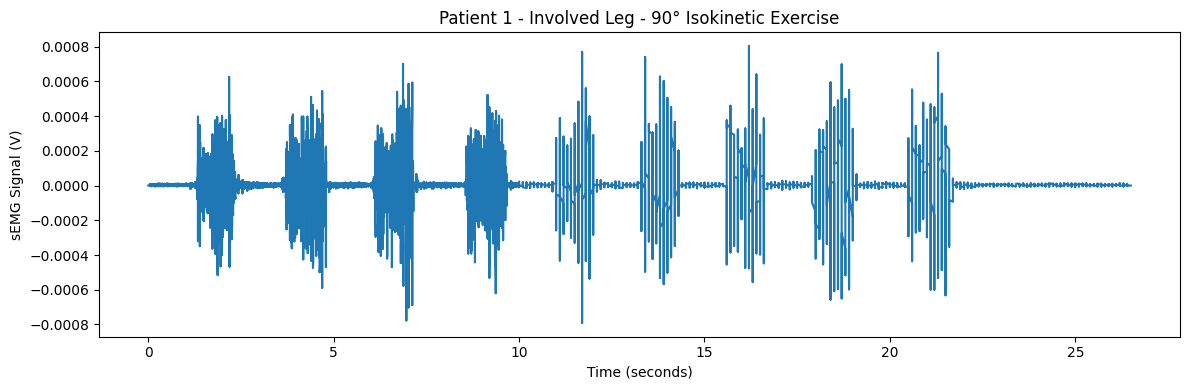

In [9]:
plt.figure(figsize=(12, 4))

plt.plot(time_p1, signal_p1)

plt.xlabel("Time (seconds)")
plt.ylabel("sEMG Signal (V)")
plt.title("Patient 1 - Involved Leg - 90° Isokinetic Exercise")

plt.tight_layout()
plt.show()

In [10]:
time_values = time_p1.to_numpy()

dt = np.diff(time_values)

print("Mean time interval:", np.mean(dt), "seconds")
print("Median time interval:", np.median(dt), "seconds")

sampling_rate = 1 / np.median(dt)

print("Estimated sampling rate:", sampling_rate, "Hz")
print("Signal duration:", time_values[-1] - time_values[0], "seconds")

Mean time interval: 0.0005197607139354713 seconds
Median time interval: 0.0 seconds
Estimated sampling rate: inf Hz
Signal duration: 26.5 seconds


/var/folders/0q/0939z_y55hj4mp2gkzrnm6040000gn/T/ipykernel_71926/2956359989.py:8: RuntimeWarning: divide by zero encountered in scalar divide
  sampling_rate = 1 / np.median(dt)


In [11]:
print("Total rows:", len(patient_90_inv))
print("Valid Patient 1 observations:", patient_90_inv["patient1"].notna().sum())
print("Missing Patient 1 observations:", patient_90_inv["patient1"].isna().sum())

print("\nFirst 10 signal values:")
print(signal_p1.head(10))

print("\nLast 10 signal values:")
print(signal_p1.tail(10))

Total rows: 56758
Valid Patient 1 observations: 50986
Missing Patient 1 observations: 5772

First 10 signal values:
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
6    0.0
7    0.0
8    0.0
9    0.0
Name: patient1, dtype: float64

Last 10 signal values:
50976    0.0
50977    0.0
50978    0.0
50979    0.0
50980    0.0
50981    0.0
50982    0.0
50983    0.0
50984    0.0
50985    0.0
Name: patient1, dtype: float64


In [13]:
dt = np.diff(time_p1.to_numpy())

positive_dt = dt[dt > 0]

print("Number of time points:", len(time_p1))
print("Number of unique time values:", time_p1.nunique())

print("\nTotal intervals:", len(dt))
print("Zero intervals:", np.sum(dt == 0))
print("Positive intervals:", np.sum(dt > 0))
print("Negative intervals:", np.sum(dt < 0))

print("\nMedian of ALL intervals:", np.median(dt))
print("Median of POSITIVE intervals:", np.median(positive_dt))
print("Mean of POSITIVE intervals:", np.mean(positive_dt))

print("\nEstimated sampling rate from positive intervals:",
      1 / np.median(positive_dt), "Hz")

Number of time points: 50986
Number of unique time values: 2159

Total intervals: 50985
Zero intervals: 48827
Positive intervals: 2158
Negative intervals: 0

Median of ALL intervals: 0.0
Median of POSITIVE intervals: 0.0010000000000000009
Mean of POSITIVE intervals: 0.012279888785912883

Estimated sampling rate from positive intervals: 999.9999999999991 Hz


In [15]:
# Cell 14: Estimate the true sampling rate from the high-resolution region

time_array = time_p1.to_numpy()

dt_full = np.diff(time_array)

# Use only very small positive intervals from the high-resolution portion
high_res_dt = dt_full[(dt_full > 0.0004) & (dt_full < 0.0007)]

sampling_interval = np.median(high_res_dt)
sampling_rate = 1 / sampling_interval

print("Number of high-resolution intervals:", len(high_res_dt))
print("Estimated sampling interval:", sampling_interval, "seconds")
print("Estimated sampling rate:", sampling_rate, "Hz")

Number of high-resolution intervals: 192
Estimated sampling interval: 0.0005000000000000004 seconds
Estimated sampling rate: 1999.9999999999982 Hz


In [16]:
# Cell 15: Check valid signal length for all patients

patient_lengths = patient_90_inv.notna().sum()

patient_summary = pd.DataFrame({
    "Participant": patient_lengths.index,
    "Valid_Samples": patient_lengths.values,
    "Duration_Seconds": patient_lengths.values / sampling_rate
})

patient_summary

,Participant,Valid_Samples,Duration_Seconds
0,patient1,50986,25.493
1,patient2,56758,28.379
2,patient3,52910,26.455
3,patient4,40404,20.202
4,patient5,47138,23.569
5,patient6,49062,24.531
6,patient7,50024,25.012
7,patient8,48100,24.050
8,patient9,54834,27.417
9,patient10,40404,20.202


In [17]:
# Cell 16: Load all 90-degree datasets

patient_90_inv = pd.read_csv(DATA_DIR / "patient_iso90_inv.csv")
patient_90_uninv = pd.read_csv(DATA_DIR / "patient_iso90_uninv.csv")

healthy_90_inv = pd.read_csv(DATA_DIR / "healthy_iso90_inv.csv")
healthy_90_uninv = pd.read_csv(DATA_DIR / "healthy_iso90_uninv.csv")

datasets_90 = {
    "Patient - Involved": patient_90_inv,
    "Patient - Uninvolved": patient_90_uninv,
    "Healthy - Involved": healthy_90_inv,
    "Healthy - Uninvolved": healthy_90_uninv
}

for name, df in datasets_90.items():
    print(f"\n{name}")
    print("Shape:", df.shape)
    print("Participants:", len(df.columns))
    print("Valid observations:", int(df.notna().sum().sum()))


Patient - Involved
Shape: (56758, 12)
Participants: 12
Valid observations: 580086

Patient - Uninvolved
Shape: (60606, 12)
Participants: 12
Valid observations: 619528

Healthy - Involved
Shape: (71188, 10)
Participants: 10
Valid observations: 492544

Healthy - Uninvolved
Shape: (76960, 10)
Participants: 10
Valid observations: 498316


In [18]:
# Cell 17: Build participant-level summary

summary_rows = []

for group_name, df in datasets_90.items():

    for participant in df.columns:

        signal = df[participant].dropna()

        summary_rows.append({
            "Group": group_name,
            "Participant": participant,
            "Valid_Samples": len(signal),
            "Duration_Seconds": len(signal) / sampling_rate,
            "Mean": signal.mean(),
            "Std": signal.std(),
            "Min": signal.min(),
            "Max": signal.max(),
            "RMS": np.sqrt(np.mean(signal ** 2))
        })

summary_90 = pd.DataFrame(summary_rows)

print("Summary shape:", summary_90.shape)

summary_90.head(10)

Summary shape: (44, 9)


,Group,Participant,Valid_Samples,Duration_Seconds,Mean,Std,Min,Max,RMS
0,Patient - Involved,patient1,50986,25.493,0.000003,0.000096,-0.000791,0.000803,0.000096
1,Patient - Involved,patient2,56758,28.379,-0.000006,0.000036,-0.000291,0.000294,0.000037
2,Patient - Involved,patient3,52910,26.455,0.000003,0.000069,-0.000643,0.000455,0.000069
3,Patient - Involved,patient4,40404,20.202,-0.000006,0.000133,-0.000881,0.001502,0.000133
4,Patient - Involved,patient5,47138,23.569,-0.000006,0.000201,-0.001708,0.001402,0.000201
5,Patient - Involved,patient6,49062,24.531,-0.000006,0.000166,-0.001187,0.000783,0.000166
6,Patient - Involved,patient7,50024,25.012,0.000003,0.000054,-0.000356,0.000522,0.000054
7,Patient - Involved,patient8,48100,24.050,0.000003,0.000083,-0.000922,0.000610,0.000083
8,Patient - Involved,patient9,54834,27.417,0.000003,0.000120,-0.001375,0.000712,0.000120
9,Patient - Involved,patient10,40404,20.202,-0.000006,0.000121,-0.000857,0.000887,0.000121


In [19]:
# Cell 18: Compare RMS across groups

rms_summary = (
    summary_90
    .groupby("Group")["RMS"]
    .agg(["count", "mean", "std", "median"])
    .round(8)
)

rms_summary

,count,mean,std,median
Group,,,,
Healthy - Involved,10,0.000100,0.000031,0.000103
Healthy - Uninvolved,10,0.000158,0.000173,0.000096
Patient - Involved,12,0.000098,0.000053,0.000089
Patient - Uninvolved,12,0.000110,0.000041,0.000104


In [20]:
# Cell 19: Compare involved vs uninvolved RMS within each participant

patient_inv_rms = summary_90[
    summary_90["Group"] == "Patient - Involved"
].set_index("Participant")["RMS"]

patient_uninv_rms = summary_90[
    summary_90["Group"] == "Patient - Uninvolved"
].set_index("Participant")["RMS"]

healthy_inv_rms = summary_90[
    summary_90["Group"] == "Healthy - Involved"
].set_index("Participant")["RMS"]

healthy_uninv_rms = summary_90[
    summary_90["Group"] == "Healthy - Uninvolved"
].set_index("Participant")["RMS"]


patient_pair = pd.DataFrame({
    "Involved_RMS": patient_inv_rms,
    "Uninvolved_RMS": patient_uninv_rms
})

healthy_pair = pd.DataFrame({
    "Involved_RMS": healthy_inv_rms,
    "Uninvolved_RMS": healthy_uninv_rms
})


# Limb Symmetry Index
patient_pair["LSI"] = (
    patient_pair["Involved_RMS"] /
    patient_pair["Uninvolved_RMS"]
)

healthy_pair["LSI"] = (
    healthy_pair["Involved_RMS"] /
    healthy_pair["Uninvolved_RMS"]
)


print("PATIENTS")
display(patient_pair)

print("\nHEALTHY")
display(healthy_pair)

PATIENTS


,Involved_RMS,Uninvolved_RMS,LSI
Participant,,,
patient1,0.000096,0.000155,0.616707
patient2,0.000037,0.000052,0.709075
patient3,0.000069,0.000106,0.651567
patient4,0.000133,0.000179,0.745950
patient5,0.000201,0.000138,1.459653
patient6,0.000166,0.000155,1.074184
patient7,0.000054,0.000066,0.811770
patient8,0.000083,0.000075,1.098155
patient9,0.000120,0.000092,1.299333



HEALTHY


,Involved_RMS,Uninvolved_RMS,LSI
Participant,,,
healthy1,0.000054,0.000046,1.181172
healthy2,0.000102,0.000134,0.759735
healthy3,0.000080,0.000068,1.173427
healthy4,0.000120,0.000250,0.478571
healthy5,0.000065,0.000075,0.867903
healthy6,0.000104,0.000103,1.005704
healthy7,0.000162,0.000205,0.788796
healthy8,0.000085,0.000003,25.213559
healthy9,0.000125,0.000603,0.208056


In [21]:
# Cell 20: Compare RMS symmetry between groups

print("Patient RMS symmetry ratio:")
print(patient_pair["LSI"].describe())

print("\nHealthy RMS symmetry ratio:")
print(healthy_pair["LSI"].describe())

Patient RMS symmetry ratio:
count    12.000000
mean      0.867134
std       0.312305
min       0.384375
25%       0.648709
50%       0.778860
75%       1.080176
max       1.459653
Name: LSI, dtype: float64

Healthy RMS symmetry ratio:
count    10.000000
mean      3.285575
std       7.711259
min       0.208056
25%       0.767000
50%       0.936804
75%       1.177479
max      25.213559
Name: LSI, dtype: float64


/var/folders/0q/0939z_y55hj4mp2gkzrnm6040000gn/T/ipykernel_71926/1441237172.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


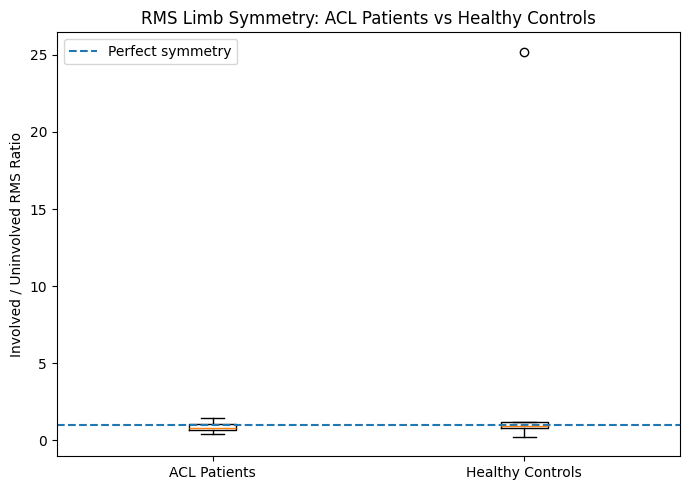

In [22]:
# Cell 21: Visualize RMS symmetry

plot_data = pd.DataFrame({
    "Patient": patient_pair["LSI"],
    "Healthy": pd.Series(healthy_pair["LSI"].values)
})

plt.figure(figsize=(7, 5))

plt.boxplot(
    [
        patient_pair["LSI"].dropna(),
        healthy_pair["LSI"].dropna()
    ],
    labels=["ACL Patients", "Healthy Controls"]
)

plt.axhline(
    y=1.0,
    linestyle="--",
    label="Perfect symmetry"
)

plt.ylabel("Involved / Uninvolved RMS Ratio")
plt.title("RMS Limb Symmetry: ACL Patients vs Healthy Controls")

plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# Cell 22: Inspect RMS symmetry ratios and identify outliers

print("PATIENT RMS RATIOS")
display(
    patient_pair
    .sort_values("LSI", ascending=False)
)

print("\nHEALTHY RMS RATIOS")
display(
    healthy_pair
    .sort_values("LSI", ascending=False)
)

PATIENT RMS RATIOS


,Involved_RMS,Uninvolved_RMS,LSI
Participant,,,
patient5,0.000201,0.000138,1.459653
patient9,0.000120,0.000092,1.299333
patient8,0.000083,0.000075,1.098155
patient6,0.000166,0.000155,1.074184
patient10,0.000121,0.000133,0.914702
patient7,0.000054,0.000066,0.811770
patient4,0.000133,0.000179,0.745950
patient2,0.000037,0.000052,0.709075
patient3,0.000069,0.000106,0.651567



HEALTHY RMS RATIOS


,Involved_RMS,Uninvolved_RMS,LSI
Participant,,,
healthy8,0.000085,0.000003,25.213559
healthy1,0.000054,0.000046,1.181172
healthy10,0.000105,0.000089,1.178830
healthy3,0.000080,0.000068,1.173427
healthy6,0.000104,0.000103,1.005704
healthy5,0.000065,0.000075,0.867903
healthy7,0.000162,0.000205,0.788796
healthy2,0.000102,0.000134,0.759735
healthy4,0.000120,0.000250,0.478571


In [24]:
# Cell 23: Check distance from perfect bilateral symmetry

patient_pair["Symmetry_Deviation"] = abs(
    np.log(patient_pair["LSI"])
)

healthy_pair["Symmetry_Deviation"] = abs(
    np.log(healthy_pair["LSI"])
)

print("Patient symmetry deviation:")
display(
    patient_pair.sort_values(
        "Symmetry_Deviation",
        ascending=False
    )
)

print("\nHealthy symmetry deviation:")
display(
    healthy_pair.sort_values(
        "Symmetry_Deviation",
        ascending=False
    )
)

Patient symmetry deviation:


,Involved_RMS,Uninvolved_RMS,LSI,Symmetry_Deviation
Participant,,,,
patient12,0.000027,0.000070,0.384375,0.956136
patient1,0.000096,0.000155,0.616707,0.483362
patient11,0.000065,0.000102,0.640134,0.446078
patient3,0.000069,0.000106,0.651567,0.428375
patient5,0.000201,0.000138,1.459653,0.378199
patient2,0.000037,0.000052,0.709075,0.343794
patient4,0.000133,0.000179,0.745950,0.293097
patient9,0.000120,0.000092,1.299333,0.261851
patient7,0.000054,0.000066,0.811770,0.208539



Healthy symmetry deviation:


,Involved_RMS,Uninvolved_RMS,LSI,Symmetry_Deviation
Participant,,,,
healthy8,0.000085,0.000003,25.213559,3.227382
healthy9,0.000125,0.000603,0.208056,1.569946
healthy4,0.000120,0.000250,0.478571,0.736951
healthy2,0.000102,0.000134,0.759735,0.274785
healthy7,0.000162,0.000205,0.788796,0.237248
healthy1,0.000054,0.000046,1.181172,0.166507
healthy10,0.000105,0.000089,1.178830,0.164523
healthy3,0.000080,0.000068,1.173427,0.159929
healthy5,0.000065,0.000075,0.867903,0.141675


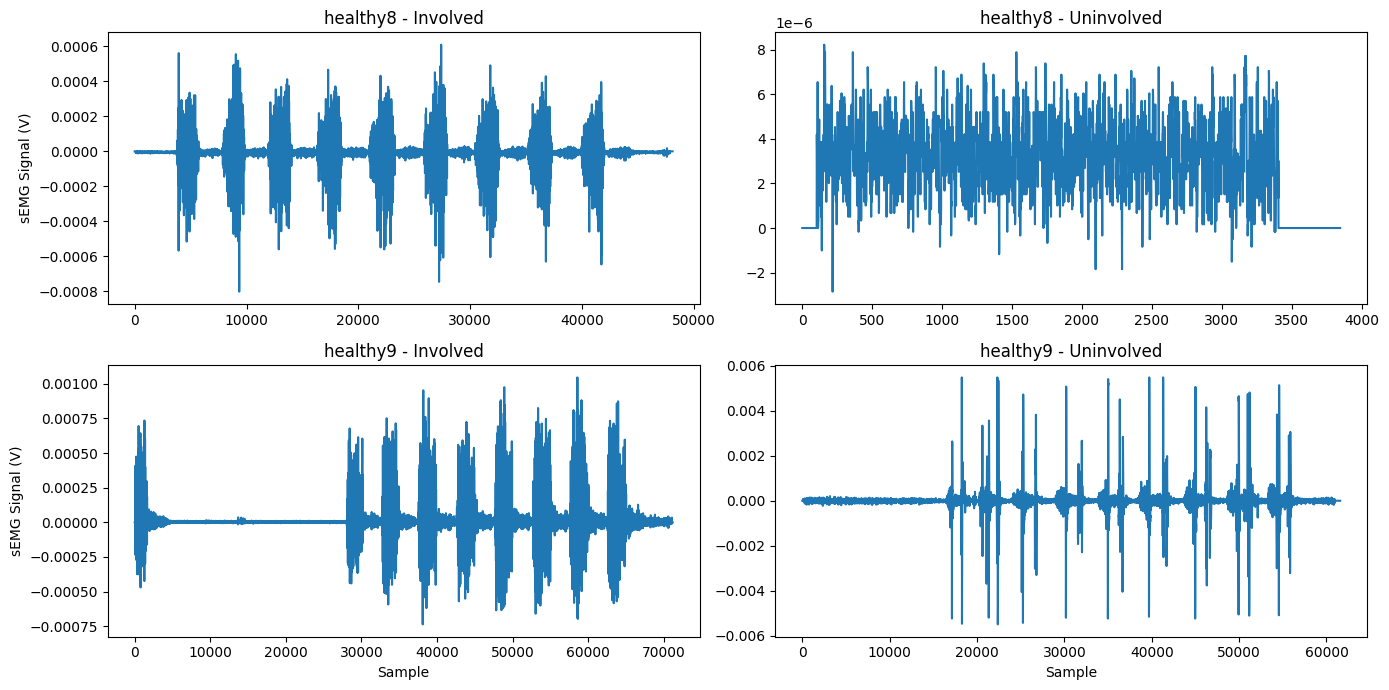

In [25]:
# Cell 24: Inspect raw signals for unusual healthy participants

fig, axes = plt.subplots(2, 2, figsize=(14, 7))

participants_to_check = ["healthy8", "healthy9"]

for row, participant in enumerate(participants_to_check):

    inv_signal = healthy_90_inv[participant].dropna().to_numpy()
    uninv_signal = healthy_90_uninv[participant].dropna().to_numpy()

    axes[row, 0].plot(inv_signal)
    axes[row, 0].set_title(f"{participant} - Involved")
    axes[row, 0].set_ylabel("sEMG Signal (V)")

    axes[row, 1].plot(uninv_signal)
    axes[row, 1].set_title(f"{participant} - Uninvolved")

axes[1, 0].set_xlabel("Sample")
axes[1, 1].set_xlabel("Sample")

plt.tight_layout()
plt.show()

In [26]:
# Cell 25: Build signal quality-control summary

qc_rows = []

for group_name, df in datasets_90.items():

    for participant in df.columns:

        signal = df[participant].dropna()

        qc_rows.append({
            "Group": group_name,
            "Participant": participant,
            "Valid_Samples": len(signal),
            "RMS": np.sqrt(np.mean(signal ** 2)),
            "Max_Abs": np.max(np.abs(signal)),
            "Zero_Fraction": np.mean(signal == 0),
            "Mean_Abs": np.mean(np.abs(signal))
        })

qc_90 = pd.DataFrame(qc_rows)

print("QC summary shape:", qc_90.shape)

qc_90.sort_values(
    "RMS",
    ascending=False
)

QC summary shape: (44, 7)


,Group,Participant,Valid_Samples,RMS,Max_Abs,Zero_Fraction,Mean_Abs
42,Healthy - Uninvolved,healthy9,61568,0.000603,0.005495,0.013465,0.000207
37,Healthy - Uninvolved,healthy4,52910,0.000250,0.002263,0.009752,0.000120
40,Healthy - Uninvolved,healthy7,60606,0.000205,0.002637,0.019206,0.000090
4,Patient - Involved,patient5,47138,0.000201,0.001708,0.021893,0.000096
15,Patient - Uninvolved,patient4,51948,0.000179,0.001853,0.010472,0.000085
5,Patient - Involved,patient6,49062,0.000166,0.001187,0.013534,0.000087
30,Healthy - Involved,healthy7,52910,0.000162,0.001647,0.020053,0.000075
12,Patient - Uninvolved,patient1,55796,0.000155,0.001520,0.008872,0.000073
17,Patient - Uninvolved,patient6,51948,0.000155,0.001148,0.021252,0.000082
16,Patient - Uninvolved,patient5,51948,0.000138,0.001388,0.009375,0.000061


In [27]:
# Cell 26: Inspect potential signal-quality problems

print("Highest RMS signals:")
display(
    qc_90.sort_values("RMS", ascending=False).head(10)
)

print("\nLowest RMS signals:")
display(
    qc_90.sort_values("RMS").head(10)
)

print("\nLargest absolute amplitudes:")
display(
    qc_90.sort_values("Max_Abs", ascending=False).head(10)
)

print("\nShortest recordings:")
display(
    qc_90.sort_values("Valid_Samples").head(10)
)

Highest RMS signals:


,Group,Participant,Valid_Samples,RMS,Max_Abs,Zero_Fraction,Mean_Abs
42,Healthy - Uninvolved,healthy9,61568,0.000603,0.005495,0.013465,0.000207
37,Healthy - Uninvolved,healthy4,52910,0.000250,0.002263,0.009752,0.000120
40,Healthy - Uninvolved,healthy7,60606,0.000205,0.002637,0.019206,0.000090
4,Patient - Involved,patient5,47138,0.000201,0.001708,0.021893,0.000096
15,Patient - Uninvolved,patient4,51948,0.000179,0.001853,0.010472,0.000085
5,Patient - Involved,patient6,49062,0.000166,0.001187,0.013534,0.000087
30,Healthy - Involved,healthy7,52910,0.000162,0.001647,0.020053,0.000075
12,Patient - Uninvolved,patient1,55796,0.000155,0.001520,0.008872,0.000073
17,Patient - Uninvolved,patient6,51948,0.000155,0.001148,0.021252,0.000082
16,Patient - Uninvolved,patient5,51948,0.000138,0.001388,0.009375,0.000061



Lowest RMS signals:


,Group,Participant,Valid_Samples,RMS,Max_Abs,Zero_Fraction,Mean_Abs
41,Healthy - Uninvolved,healthy8,3848,0.000003,0.000008,0.143971,0.000003
11,Patient - Involved,patient12,50986,0.000027,0.000853,0.012964,0.000013
1,Patient - Involved,patient2,56758,0.000037,0.000294,0.016438,0.000020
34,Healthy - Uninvolved,healthy1,57720,0.000046,0.000463,0.015870,0.000026
13,Patient - Uninvolved,patient2,49062,0.000052,0.000397,0.014431,0.000032
6,Patient - Involved,patient7,50024,0.000054,0.000522,0.020910,0.000029
24,Healthy - Involved,healthy1,47138,0.000054,0.000571,0.013492,0.000031
10,Patient - Involved,patient11,38480,0.000065,0.000639,0.028326,0.000034
28,Healthy - Involved,healthy5,58682,0.000065,0.000750,0.013496,0.000033
18,Patient - Uninvolved,patient7,55796,0.000066,0.000868,0.015557,0.000034



Largest absolute amplitudes:


,Group,Participant,Valid_Samples,RMS,Max_Abs,Zero_Fraction,Mean_Abs
42,Healthy - Uninvolved,healthy9,61568,0.000603,0.005495,0.013465,0.000207
40,Healthy - Uninvolved,healthy7,60606,0.000205,0.002637,0.019206,0.000090
37,Healthy - Uninvolved,healthy4,52910,0.000250,0.002263,0.009752,0.000120
15,Patient - Uninvolved,patient4,51948,0.000179,0.001853,0.010472,0.000085
4,Patient - Involved,patient5,47138,0.000201,0.001708,0.021893,0.000096
14,Patient - Uninvolved,patient3,56758,0.000106,0.001660,0.016632,0.000053
30,Healthy - Involved,healthy7,52910,0.000162,0.001647,0.020053,0.000075
12,Patient - Uninvolved,patient1,55796,0.000155,0.001520,0.008872,0.000073
3,Patient - Involved,patient4,40404,0.000133,0.001502,0.021805,0.000070
16,Patient - Uninvolved,patient5,51948,0.000138,0.001388,0.009375,0.000061



Shortest recordings:


,Group,Participant,Valid_Samples,RMS,Max_Abs,Zero_Fraction,Mean_Abs
41,Healthy - Uninvolved,healthy8,3848,0.000003,0.000008,0.143971,0.000003
29,Healthy - Involved,healthy6,31746,0.000104,0.000710,0.036981,0.000055
26,Healthy - Involved,healthy3,38480,0.000080,0.000565,0.025390,0.000044
10,Patient - Involved,patient11,38480,0.000065,0.000639,0.028326,0.000034
39,Healthy - Uninvolved,healthy6,39442,0.000103,0.000873,0.009989,0.000050
3,Patient - Involved,patient4,40404,0.000133,0.001502,0.021805,0.000070
9,Patient - Involved,patient10,40404,0.000121,0.000887,0.020617,0.000066
21,Patient - Uninvolved,patient10,42328,0.000133,0.001020,0.016230,0.000068
43,Healthy - Uninvolved,healthy10,42328,0.000089,0.000827,0.003709,0.000049
25,Healthy - Involved,healthy2,44252,0.000102,0.000953,0.015660,0.000057


In [28]:
# Cell 27: Flag clearly suspicious recordings

qc_90["QC_Flag"] = "OK"

qc_90.loc[
    (qc_90["Group"] == "Healthy - Uninvolved") &
    (qc_90["Participant"] == "healthy8"),
    "QC_Flag"
] = "Review - unusually short / very low amplitude"

qc_90.loc[
    (qc_90["Group"] == "Healthy - Uninvolved") &
    (qc_90["Participant"] == "healthy9"),
    "QC_Flag"
] = "Review - extreme amplitude spikes"

display(
    qc_90[qc_90["QC_Flag"] != "OK"]
)

,Group,Participant,Valid_Samples,RMS,Max_Abs,Zero_Fraction,Mean_Abs,QC_Flag
41,Healthy - Uninvolved,healthy8,3848,0.000003,0.000008,0.143971,0.000003,Review - unusually short / very low amplitude
42,Healthy - Uninvolved,healthy9,61568,0.000603,0.005495,0.013465,0.000207,Review - extreme amplitude spikes


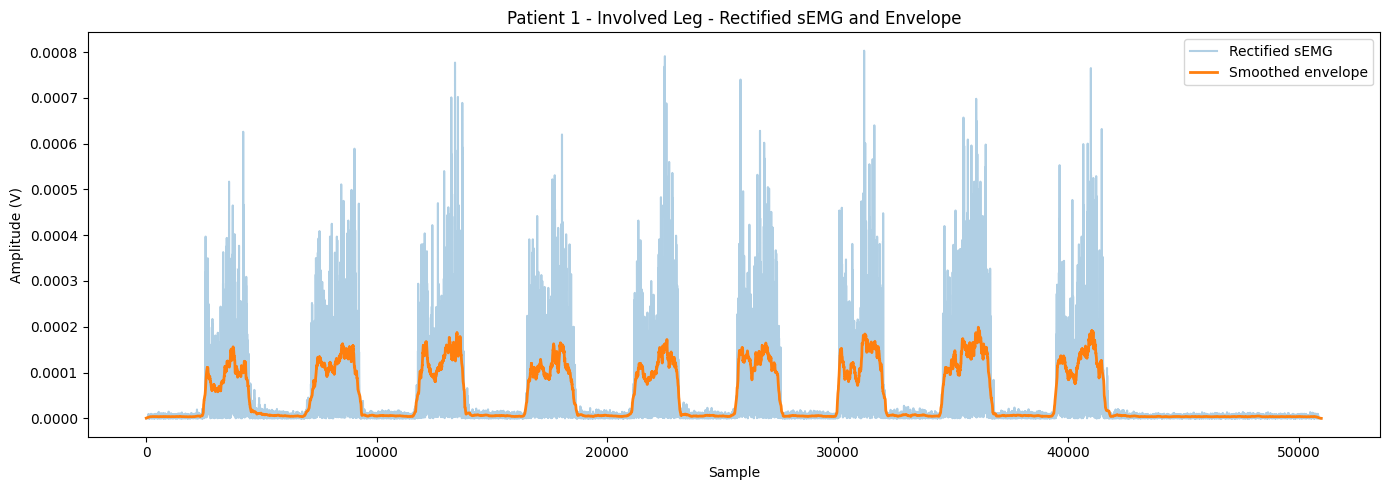

In [29]:
# Cell 28: Create rectified signal and smoothed envelope for Patient 1

signal = patient_90_inv["patient1"].dropna().to_numpy()

# Rectify the raw sEMG signal
rectified = np.abs(signal)

# Moving-average envelope
window_size = 200

envelope = np.convolve(
    rectified,
    np.ones(window_size) / window_size,
    mode="same"
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(rectified, alpha=0.35, label="Rectified sEMG")
ax.plot(envelope, linewidth=2, label="Smoothed envelope")

ax.set_title("Patient 1 - Involved Leg - Rectified sEMG and Envelope")
ax.set_xlabel("Sample")
ax.set_ylabel("Amplitude (V)")
ax.legend()

plt.tight_layout()
plt.show()

In [30]:
# Cell 29: Detect active contraction regions

# Estimate baseline from the lower part of the envelope
baseline = np.percentile(envelope, 20)

# Estimate signal spread
mad = np.median(np.abs(envelope - np.median(envelope)))

# Adaptive threshold
threshold = baseline + 5 * mad

active = envelope > threshold

print("Baseline:", baseline)
print("MAD:", mad)
print("Detection threshold:", threshold)
print("Active samples:", active.sum())
print("Active fraction:", active.mean())

Baseline: 4.150755000000001e-06
MAD: 2.735825000000001e-06
Detection threshold: 1.7829880000000006e-05
Active samples: 19455
Active fraction: 0.3815753344055231


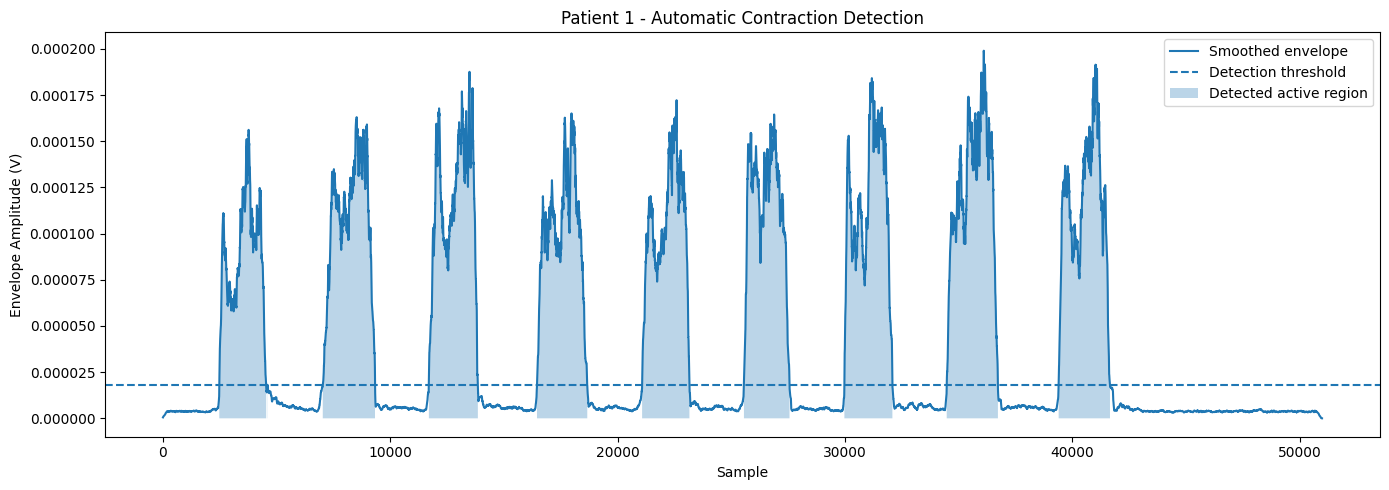

In [31]:
# Cell 30: Visualize contraction detection threshold

plt.figure(figsize=(14, 5))

plt.plot(envelope, label="Smoothed envelope")
plt.axhline(
    threshold,
    linestyle="--",
    label="Detection threshold"
)

plt.fill_between(
    np.arange(len(envelope)),
    0,
    envelope,
    where=active,
    alpha=0.3,
    label="Detected active region"
)

plt.title("Patient 1 - Automatic Contraction Detection")
plt.xlabel("Sample")
plt.ylabel("Envelope Amplitude (V)")
plt.legend()

plt.tight_layout()
plt.show()

In [32]:
# Cell 31: Convert active samples into contraction segments

active_int = active.astype(int)

# Detect transitions
changes = np.diff(active_int)

starts = np.where(changes == 1)[0] + 1
ends = np.where(changes == -1)[0] + 1

# Handle edge cases
if active[0]:
    starts = np.insert(starts, 0, 0)

if active[-1]:
    ends = np.append(ends, len(active))

segments = pd.DataFrame({
    "Start_Sample": starts,
    "End_Sample": ends
})

segments["Duration_Samples"] = (
    segments["End_Sample"] -
    segments["Start_Sample"]
)

print("Number of detected contractions:", len(segments))

segments

Number of detected contractions: 10


,Start_Sample,End_Sample,Duration_Samples
0,2476,4541,2065
1,4599,4609,10
2,7029,9327,2298
3,11696,13852,2156
4,16452,18665,2213
5,21076,23158,2082
6,25555,27561,2006
7,29974,32086,2112
8,34475,36728,2253
9,39398,41658,2260


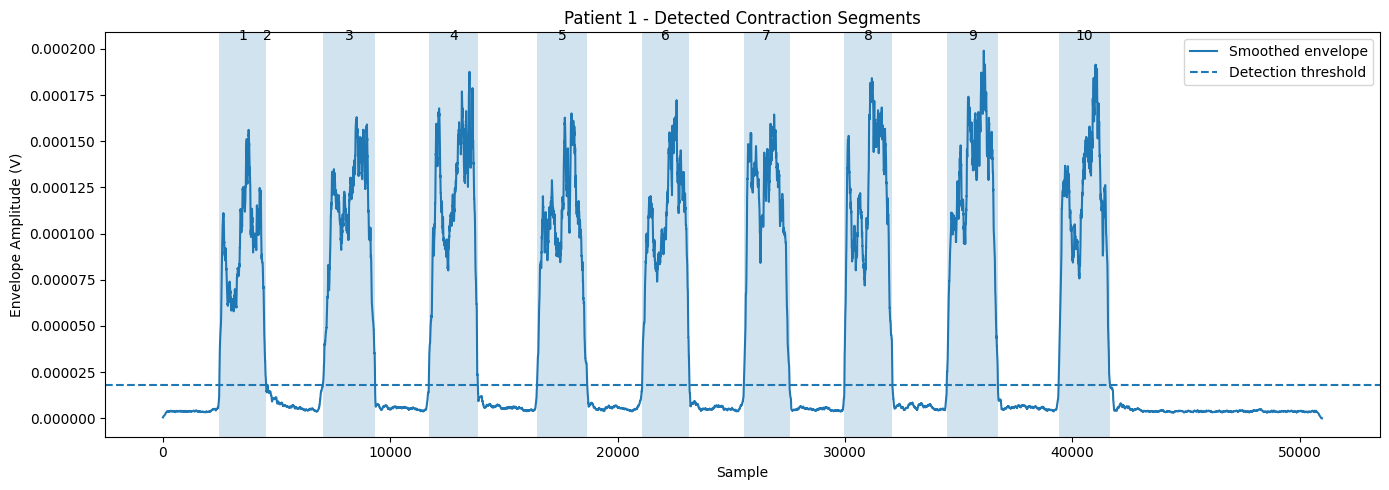

In [33]:
# Cell 32: Visualize detected contraction segments

plt.figure(figsize=(14, 5))

plt.plot(envelope, label="Smoothed envelope")

for i, row in segments.iterrows():
    plt.axvspan(
        row["Start_Sample"],
        row["End_Sample"],
        alpha=0.2
    )

    midpoint = (
        row["Start_Sample"] +
        row["End_Sample"]
    ) / 2

    plt.text(
        midpoint,
        envelope.max() * 1.03,
        str(i + 1),
        ha="center"
    )

plt.axhline(
    threshold,
    linestyle="--",
    label="Detection threshold"
)

plt.title("Patient 1 - Detected Contraction Segments")
plt.xlabel("Sample")
plt.ylabel("Envelope Amplitude (V)")
plt.legend()

plt.tight_layout()
plt.show()

In [34]:
# Cell 33: Remove unrealistically short contraction segments

min_duration_seconds = 0.5
min_duration_samples = int(min_duration_seconds * sampling_rate)

segments_clean = segments[
    segments["Duration_Samples"] >= min_duration_samples
].copy()

segments_clean = segments_clean.reset_index(drop=True)

segments_clean["Contraction"] = np.arange(
    1,
    len(segments_clean) + 1
)

segments_clean["Duration_Seconds"] = (
    segments_clean["Duration_Samples"] / sampling_rate
)

print("Minimum duration threshold:", min_duration_seconds, "seconds")
print("Number of contractions before filtering:", len(segments))
print("Number of contractions after filtering:", len(segments_clean))

segments_clean

Minimum duration threshold: 0.5 seconds
Number of contractions before filtering: 10
Number of contractions after filtering: 9


,Start_Sample,End_Sample,Duration_Samples,Contraction,Duration_Seconds
0,2476,4541,2065,1,1.0325
1,7029,9327,2298,2,1.1490
2,11696,13852,2156,3,1.0780
3,16452,18665,2213,4,1.1065
4,21076,23158,2082,5,1.0410
5,25555,27561,2006,6,1.0030
6,29974,32086,2112,7,1.0560
7,34475,36728,2253,8,1.1265
8,39398,41658,2260,9,1.1300


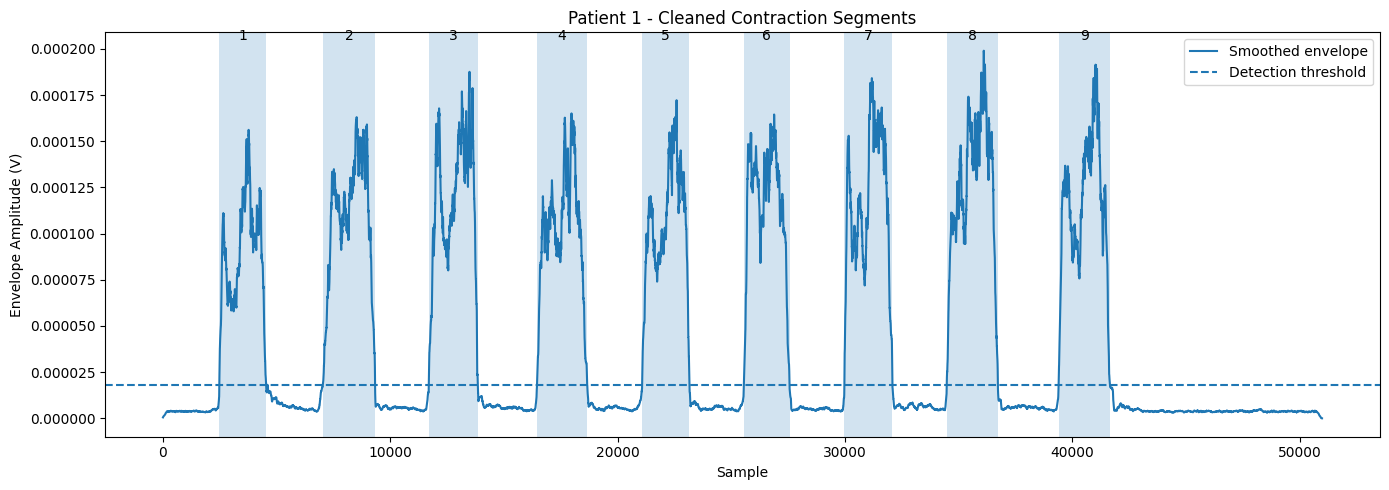

In [35]:
# Cell 34: Visualize cleaned contraction segments

plt.figure(figsize=(14, 5))

plt.plot(envelope, label="Smoothed envelope")

for _, row in segments_clean.iterrows():

    plt.axvspan(
        row["Start_Sample"],
        row["End_Sample"],
        alpha=0.2
    )

    midpoint = (
        row["Start_Sample"] +
        row["End_Sample"]
    ) / 2

    plt.text(
        midpoint,
        envelope.max() * 1.03,
        int(row["Contraction"]),
        ha="center"
    )

plt.axhline(
    threshold,
    linestyle="--",
    label="Detection threshold"
)

plt.title("Patient 1 - Cleaned Contraction Segments")
plt.xlabel("Sample")
plt.ylabel("Envelope Amplitude (V)")
plt.legend()

plt.tight_layout()
plt.show()

In [36]:
# Cell 35: Extract contraction-level features for Patient 1

contraction_features = []

for _, row in segments_clean.iterrows():

    start = int(row["Start_Sample"])
    end = int(row["End_Sample"])

    # Extract raw sEMG signal for this contraction
    segment = signal_p1.iloc[start:end].to_numpy()

    # Calculate features
    rms = np.sqrt(np.mean(segment ** 2))
    mav = np.mean(np.abs(segment))
    peak = np.max(np.abs(segment))

    contraction_features.append({
        "Contraction": int(row["Contraction"]),
        "Start_Sample": start,
        "End_Sample": end,
        "Duration_Seconds": row["Duration_Seconds"],
        "RMS": rms,
        "MAV": mav,
        "Peak_Amplitude": peak
    })

features_p1 = pd.DataFrame(contraction_features)

features_p1

,Contraction,Start_Sample,End_Sample,Duration_Seconds,RMS,MAV,Peak_Amplitude
0,1,2476,4541,1.0325,0.000127,0.000090,0.000626
1,2,7029,9327,1.1490,0.000148,0.000109,0.000589
2,3,11696,13852,1.0780,0.000164,0.000119,0.000777
3,4,16452,18665,1.1065,0.000140,0.000103,0.000620
4,5,21076,23158,1.0410,0.000149,0.000107,0.000791
5,6,25555,27561,1.0030,0.000160,0.000118,0.000740
6,7,29974,32086,1.0560,0.000162,0.000120,0.000803
7,8,34475,36728,1.1265,0.000175,0.000127,0.000698
8,9,39398,41658,1.1300,0.000160,0.000117,0.000765


In [37]:
# Cell 36: Summarize contraction-level features

print("Patient 1 - Involved Leg")
print("Number of contractions:", len(features_p1))

display(
    features_p1[
        ["Duration_Seconds", "RMS", "MAV", "Peak_Amplitude"]
    ].describe()
)

print("\nRMS coefficient of variation:")

rms_cv = (
    features_p1["RMS"].std()
    / features_p1["RMS"].mean()
)

print(rms_cv)

Patient 1 - Involved Leg
Number of contractions: 9


,Duration_Seconds,RMS,MAV,Peak_Amplitude
count,9.000000,9.000000,9.000000,9.000000
mean,1.080278,0.000154,0.000112,0.000712
std,0.050511,0.000014,0.000011,0.000082
min,1.003000,0.000127,0.000090,0.000589
25%,1.041000,0.000148,0.000107,0.000626
50%,1.078000,0.000160,0.000117,0.000740
75%,1.126500,0.000162,0.000119,0.000777
max,1.149000,0.000175,0.000127,0.000803



RMS coefficient of variation:
0.09342533902959455


In [38]:
# Cell 37: Detect contractions for Patient 1 uninvolved leg

signal_p1_uninv = patient_90_uninv["patient1"].dropna().reset_index(drop=True)

# Rectify signal
rectified_uninv = np.abs(signal_p1_uninv.to_numpy())

# Smooth using the same window as involved leg
window_samples = int(0.05 * sampling_rate)

envelope_uninv = (
    pd.Series(rectified_uninv)
    .rolling(
        window=window_samples,
        center=True,
        min_periods=1
    )
    .mean()
    .to_numpy()
)

# Calculate threshold using the same method
baseline_uninv = np.percentile(envelope_uninv, 20)

threshold_uninv = baseline_uninv * 3

active_uninv = envelope_uninv > threshold_uninv

print("Signal length:", len(signal_p1_uninv))
print("Baseline:", baseline_uninv)
print("Detection threshold:", threshold_uninv)
print("Active fraction:", active_uninv.mean())

Signal length: 55796
Baseline: 6.322171717171717e-06
Detection threshold: 1.8966515151515153e-05
Active fraction: 0.3754390995770306


In [39]:
# Cell 38: Find contraction segments for Patient 1 uninvolved leg

changes = np.diff(active_uninv.astype(int))

starts = np.where(changes == 1)[0] + 1
ends = np.where(changes == -1)[0] + 1

# Handle active region at beginning/end
if active_uninv[0]:
    starts = np.insert(starts, 0, 0)

if active_uninv[-1]:
    ends = np.append(ends, len(active_uninv))

segments_uninv = pd.DataFrame({
    "Start_Sample": starts,
    "End_Sample": ends
})

segments_uninv["Duration_Samples"] = (
    segments_uninv["End_Sample"]
    - segments_uninv["Start_Sample"]
)

# Remove short false detections
segments_uninv_clean = segments_uninv[
    segments_uninv["Duration_Samples"] >= min_duration_samples
].copy()

segments_uninv_clean.reset_index(drop=True, inplace=True)

segments_uninv_clean["Contraction"] = (
    np.arange(1, len(segments_uninv_clean) + 1)
)

segments_uninv_clean["Duration_Seconds"] = (
    segments_uninv_clean["Duration_Samples"]
    / sampling_rate
)

print("Raw detected regions:", len(segments_uninv))
print("Valid contractions:", len(segments_uninv_clean))

segments_uninv_clean

Raw detected regions: 13
Valid contractions: 9


,Start_Sample,End_Sample,Duration_Samples,Contraction,Duration_Seconds
0,919,3137,2218,1,1.1090
1,5563,7909,2346,2,1.1730
2,10385,12627,2242,3,1.1210
3,15265,17440,2175,4,1.0875
4,20163,22481,2318,5,1.1590
5,25137,27527,2390,6,1.1950
6,30170,32545,2375,7,1.1875
7,35099,37322,2223,8,1.1115
8,40113,42407,2294,9,1.1470


In [40]:
# Cell 39: Extract contraction-level features for Patient 1 uninvolved leg

contraction_features_uninv = []

for _, row in segments_uninv_clean.iterrows():

    start = int(row["Start_Sample"])
    end = int(row["End_Sample"])

    segment = signal_p1_uninv.iloc[start:end].to_numpy()

    rms = np.sqrt(np.mean(segment ** 2))
    mav = np.mean(np.abs(segment))
    peak = np.max(np.abs(segment))

    contraction_features_uninv.append({
        "Contraction": int(row["Contraction"]),
        "Start_Sample": start,
        "End_Sample": end,
        "Duration_Seconds": row["Duration_Seconds"],
        "RMS": rms,
        "MAV": mav,
        "Peak_Amplitude": peak
    })

features_p1_uninv = pd.DataFrame(contraction_features_uninv)

features_p1_uninv

,Contraction,Start_Sample,End_Sample,Duration_Seconds,RMS,MAV,Peak_Amplitude
0,1,919,3137,1.1090,0.000224,0.000160,0.001000
1,2,5563,7909,1.1730,0.000237,0.000175,0.001380
2,3,10385,12627,1.1210,0.000205,0.000148,0.000873
3,4,15265,17440,1.0875,0.000312,0.000229,0.001520
4,5,20163,22481,1.1590,0.000275,0.000204,0.001200
5,6,25137,27527,1.1950,0.000275,0.000208,0.001330
6,7,30170,32545,1.1875,0.000258,0.000190,0.001510
7,8,35099,37322,1.1115,0.000266,0.000200,0.001150
8,9,40113,42407,1.1470,0.000226,0.000163,0.000963


In [41]:
# Cell 40: Compare Patient 1 involved vs uninvolved contraction features

comparison_p1 = pd.DataFrame({
    "Feature": ["RMS", "MAV", "Peak_Amplitude", "Duration_Seconds"],
    "Involved_Mean": [
        features_p1["RMS"].mean(),
        features_p1["MAV"].mean(),
        features_p1["Peak_Amplitude"].mean(),
        features_p1["Duration_Seconds"].mean()
    ],
    "Uninvolved_Mean": [
        features_p1_uninv["RMS"].mean(),
        features_p1_uninv["MAV"].mean(),
        features_p1_uninv["Peak_Amplitude"].mean(),
        features_p1_uninv["Duration_Seconds"].mean()
    ]
})

comparison_p1["Involved_Uninvolved_Ratio"] = (
    comparison_p1["Involved_Mean"] /
    comparison_p1["Uninvolved_Mean"]
)

comparison_p1

,Feature,Involved_Mean,Uninvolved_Mean,Involved_Uninvolved_Ratio
0,RMS,0.000154,0.000253,0.607649
1,MAV,0.000112,0.000186,0.602372
2,Peak_Amplitude,0.000712,0.001214,0.586582
3,Duration_Seconds,1.080278,1.143389,0.944803


In [42]:
# Cell 41: Calculate Patient 1 active RMS symmetry

mean_rms_inv = features_p1["RMS"].mean()
mean_rms_uninv = features_p1_uninv["RMS"].mean()

active_rms_ratio = mean_rms_inv / mean_rms_uninv
active_symmetry_deviation = abs(np.log(active_rms_ratio))

print("Mean active RMS - involved:", mean_rms_inv)
print("Mean active RMS - uninvolved:", mean_rms_uninv)
print("Active RMS ratio:", active_rms_ratio)
print("Active symmetry deviation:", active_symmetry_deviation)

Mean active RMS - involved: 0.00015374926755607962
Mean active RMS - uninvolved: 0.00025302307374059144
Active RMS ratio: 0.607649196901738
Active symmetry deviation: 0.4981575423123165


In [43]:
# Cell 42: Create reusable contraction feature extraction function

def extract_contraction_features(
    signal,
    sampling_rate=2000,
    smoothing_seconds=0.05,
    baseline_percentile=20,
    threshold_multiplier=3,
    min_duration_seconds=0.5
):
    
    # Clean signal
    signal = pd.Series(signal).dropna().reset_index(drop=True)

    raw = signal.to_numpy()

    # Rectification
    rectified = np.abs(raw)

    # Smoothed envelope
    window_samples = int(smoothing_seconds * sampling_rate)

    envelope = (
        pd.Series(rectified)
        .rolling(
            window=window_samples,
            center=True,
            min_periods=1
        )
        .mean()
        .to_numpy()
    )

    # Adaptive threshold
    baseline = np.percentile(envelope, baseline_percentile)
    threshold = baseline * threshold_multiplier

    active = envelope > threshold

    # Find active regions
    changes = np.diff(active.astype(int))

    starts = np.where(changes == 1)[0] + 1
    ends = np.where(changes == -1)[0] + 1

    if active[0]:
        starts = np.insert(starts, 0, 0)

    if active[-1]:
        ends = np.append(ends, len(active))

    segments = pd.DataFrame({
        "Start_Sample": starts,
        "End_Sample": ends
    })

    segments["Duration_Samples"] = (
        segments["End_Sample"] - segments["Start_Sample"]
    )

    # Remove unrealistically short detections
    min_samples = int(min_duration_seconds * sampling_rate)

    segments = segments[
        segments["Duration_Samples"] >= min_samples
    ].copy()

    segments.reset_index(drop=True, inplace=True)

    # Extract contraction-level features
    feature_rows = []

    for i, row in segments.iterrows():

        start = int(row["Start_Sample"])
        end = int(row["End_Sample"])

        segment = raw[start:end]

        feature_rows.append({
            "Contraction": i + 1,
            "Start_Sample": start,
            "End_Sample": end,
            "Duration_Seconds": (end - start) / sampling_rate,
            "RMS": np.sqrt(np.mean(segment ** 2)),
            "MAV": np.mean(np.abs(segment)),
            "Peak_Amplitude": np.max(np.abs(segment))
        })

    features = pd.DataFrame(feature_rows)

    diagnostics = {
        "Signal_Length": len(raw),
        "Baseline": baseline,
        "Threshold": threshold,
        "Raw_Regions": len(starts),
        "Valid_Contractions": len(features),
        "Active_Fraction": active.mean()
    }

    return features, diagnostics, envelope, threshold

In [44]:
# Cell 43: Validate reusable function on Patient 1

test_inv_features, test_inv_diag, _, _ = (
    extract_contraction_features(
        patient_90_inv["patient1"],
        sampling_rate=sampling_rate
    )
)

test_uninv_features, test_uninv_diag, _, _ = (
    extract_contraction_features(
        patient_90_uninv["patient1"],
        sampling_rate=sampling_rate
    )
)

print("INVOLVED")
print(test_inv_diag)

print("\nUNINVOLVED")
print(test_uninv_diag)

print("\nMean active RMS:")
print(
    "Involved:",
    test_inv_features["RMS"].mean()
)
print(
    "Uninvolved:",
    test_uninv_features["RMS"].mean()
)

print(
    "\nRMS ratio:",
    test_inv_features["RMS"].mean()
    / test_uninv_features["RMS"].mean()
)

INVOLVED
{'Signal_Length': 50986, 'Baseline': 4.1415454545454545e-06, 'Threshold': 1.2424636363636363e-05, 'Raw_Regions': 14, 'Valid_Contractions': 9, 'Active_Fraction': 0.3879888596869729}

UNINVOLVED
{'Signal_Length': 55796, 'Baseline': 6.322171717171717e-06, 'Threshold': 1.8966515151515153e-05, 'Raw_Regions': 13, 'Valid_Contractions': 9, 'Active_Fraction': 0.3754390995770306}

Mean active RMS:
Involved: 0.00015437067934092276
Uninvolved: 0.00025302307374059144

RMS ratio: 0.6101051459804384


In [45]:
# Cell 44: Batch contraction detection QC for all participants

qc_rows = []

for group_name, df in datasets_90.items():

    for participant in df.columns:

        features, diagnostics, _, _ = extract_contraction_features(
            df[participant],
            sampling_rate=sampling_rate
        )

        qc_rows.append({
            "Group": group_name,
            "Participant": participant,
            "Signal_Length": diagnostics["Signal_Length"],
            "Raw_Regions": diagnostics["Raw_Regions"],
            "Valid_Contractions": diagnostics["Valid_Contractions"],
            "Active_Fraction": diagnostics["Active_Fraction"],
            "Threshold": diagnostics["Threshold"],
            "Mean_Active_RMS": (
                features["RMS"].mean()
                if len(features) > 0
                else np.nan
            )
        })


qc_summary = pd.DataFrame(qc_rows)

print("QC summary shape:", qc_summary.shape)

display(qc_summary)

QC summary shape: (44, 8)


,Group,Participant,Signal_Length,Raw_Regions,Valid_Contractions,Active_Fraction,Threshold,Mean_Active_RMS
0,Patient - Involved,patient1,50986,14,9,0.387989,0.000012,0.000154
1,Patient - Involved,patient2,56758,22,9,0.316977,0.000018,0.000065
2,Patient - Involved,patient3,52910,17,8,0.386260,0.000015,0.000113
3,Patient - Involved,patient4,40404,10,9,0.441862,0.000022,0.000200
4,Patient - Involved,patient5,47138,21,9,0.378230,0.000018,0.000328
5,Patient - Involved,patient6,49062,13,8,0.418450,0.000029,0.000259
6,Patient - Involved,patient7,50024,97,9,0.515712,0.000012,0.000084
7,Patient - Involved,patient8,48100,107,9,0.528212,0.000012,0.000131
8,Patient - Involved,patient9,54834,27,9,0.401758,0.000019,0.000190
9,Patient - Involved,patient10,40404,11,8,0.444040,0.000028,0.000181


In [46]:
# Cell 45: Inspect contraction counts across all recordings

contraction_count_summary = (
    qc_summary
    .groupby("Group")["Valid_Contractions"]
    .agg(["count", "mean", "std", "min", "median", "max"])
)

display(contraction_count_summary)

print("\nRecordings sorted by number of valid contractions:")

display(
    qc_summary[
        [
            "Group",
            "Participant",
            "Valid_Contractions",
            "Raw_Regions",
            "Active_Fraction",
            "Mean_Active_RMS"
        ]
    ]
    .sort_values(
        ["Valid_Contractions", "Group"]
    )
)

,count,mean,std,min,median,max
Group,,,,,,
Healthy - Involved,10,8.800000,0.788811,7,9.0,10
Healthy - Uninvolved,10,7.800000,2.820559,0,9.0,9
Patient - Involved,12,8.416667,1.164500,5,9.0,9
Patient - Uninvolved,12,9.000000,0.426401,8,9.0,10



Recordings sorted by number of valid contractions:


,Group,Participant,Valid_Contractions,Raw_Regions,Active_Fraction,Mean_Active_RMS
41,Healthy - Uninvolved,healthy8,0,0,0.000000,NaN
11,Patient - Involved,patient12,5,83,0.305496,0.000052
26,Healthy - Involved,healthy3,7,12,0.407017,0.000125
42,Healthy - Uninvolved,healthy9,7,74,0.309008,0.000989
29,Healthy - Involved,healthy6,8,11,0.430826,0.000159
36,Healthy - Uninvolved,healthy3,8,42,0.468893,0.000107
2,Patient - Involved,patient3,8,17,0.386260,0.000113
5,Patient - Involved,patient6,8,13,0.418450,0.000259
9,Patient - Involved,patient10,8,11,0.444040,0.000181
13,Patient - Uninvolved,patient2,8,37,0.405487,0.000081


In [47]:
# Cell 46: Create recording-level QC flags

qc_final = qc_summary.copy()

def assign_qc_status(row):

    # Clearly unusable recording
    if row["Valid_Contractions"] == 0:
        return "Exclude - no valid contractions"

    # Too few usable contractions
    if row["Valid_Contractions"] < 7:
        return "Review - low contraction count"

    # Unusually high active RMS
    if row["Mean_Active_RMS"] > 0.0005:
        return "Review - amplitude outlier"

    return "Pass"


qc_final["QC_Status"] = qc_final.apply(
    assign_qc_status,
    axis=1
)

display(
    qc_final[
        [
            "Group",
            "Participant",
            "Signal_Length",
            "Valid_Contractions",
            "Active_Fraction",
            "Mean_Active_RMS",
            "QC_Status"
        ]
    ]
)

print("\nQC status counts:")
print(qc_final["QC_Status"].value_counts())

,Group,Participant,Signal_Length,Valid_Contractions,Active_Fraction,Mean_Active_RMS,QC_Status
0,Patient - Involved,patient1,50986,9,0.387989,0.000154,Pass
1,Patient - Involved,patient2,56758,9,0.316977,0.000065,Pass
2,Patient - Involved,patient3,52910,8,0.386260,0.000113,Pass
3,Patient - Involved,patient4,40404,9,0.441862,0.000200,Pass
4,Patient - Involved,patient5,47138,9,0.378230,0.000328,Pass
5,Patient - Involved,patient6,49062,8,0.418450,0.000259,Pass
6,Patient - Involved,patient7,50024,9,0.515712,0.000084,Pass
7,Patient - Involved,patient8,48100,9,0.528212,0.000131,Pass
8,Patient - Involved,patient9,54834,9,0.401758,0.000190,Pass
9,Patient - Involved,patient10,40404,8,0.444040,0.000181,Pass



QC status counts:
QC_Status
Pass                               41
Review - low contraction count      1
Exclude - no valid contractions     1
Review - amplitude outlier          1
Name: count, dtype: int64


In [48]:
# Cell 47: Build bilateral QC table

qc_bilateral = (
    qc_final
    .pivot(
        index="Participant",
        columns="Group",
        values="QC_Status"
    )
)

display(qc_bilateral)

Group,Healthy - Involved,Healthy - Uninvolved,Patient - Involved,Patient - Uninvolved
Participant,,,,
healthy1,Pass,Pass,NaN,NaN
healthy10,Pass,Pass,NaN,NaN
healthy2,Pass,Pass,NaN,NaN
healthy3,Pass,Pass,NaN,NaN
healthy4,Pass,Pass,NaN,NaN
healthy5,Pass,Pass,NaN,NaN
healthy6,Pass,Pass,NaN,NaN
healthy7,Pass,Pass,NaN,NaN
healthy8,Pass,Exclude - no valid contractions,NaN,NaN


In [49]:
# Cell 48: Build participant-level bilateral active RMS dataset

bilateral_rows = []

# Patient group
for i in range(1, 13):

    participant = f"patient{i}"

    inv_features, inv_diag, _, _ = extract_contraction_features(
        patient_90_inv[participant],
        sampling_rate=sampling_rate
    )

    uninv_features, uninv_diag, _, _ = extract_contraction_features(
        patient_90_uninv[participant],
        sampling_rate=sampling_rate
    )

    bilateral_rows.append({
        "Cohort": "ACL Patient",
        "Participant": participant,

        "Involved_RMS": inv_features["RMS"].mean()
            if len(inv_features) > 0 else np.nan,

        "Uninvolved_RMS": uninv_features["RMS"].mean()
            if len(uninv_features) > 0 else np.nan,

        "Involved_Contractions": inv_diag["Valid_Contractions"],
        "Uninvolved_Contractions": uninv_diag["Valid_Contractions"]
    })


# Healthy group
for i in range(1, 11):

    participant = f"healthy{i}"

    inv_features, inv_diag, _, _ = extract_contraction_features(
        healthy_90_inv[participant],
        sampling_rate=sampling_rate
    )

    uninv_features, uninv_diag, _, _ = extract_contraction_features(
        healthy_90_uninv[participant],
        sampling_rate=sampling_rate
    )

    bilateral_rows.append({
        "Cohort": "Healthy Control",
        "Participant": participant,

        "Involved_RMS": inv_features["RMS"].mean()
            if len(inv_features) > 0 else np.nan,

        "Uninvolved_RMS": uninv_features["RMS"].mean()
            if len(uninv_features) > 0 else np.nan,

        "Involved_Contractions": inv_diag["Valid_Contractions"],
        "Uninvolved_Contractions": uninv_diag["Valid_Contractions"]
    })


bilateral_active = pd.DataFrame(bilateral_rows)

display(bilateral_active)

,Cohort,Participant,Involved_RMS,Uninvolved_RMS,Involved_Contractions,Uninvolved_Contractions
0,ACL Patient,patient1,0.000154,0.000253,9,9
1,ACL Patient,patient2,0.000065,0.000081,9,8
2,ACL Patient,patient3,0.000113,0.000176,8,9
3,ACL Patient,patient4,0.000200,0.000284,9,10
4,ACL Patient,patient5,0.000328,0.000239,9,9
5,ACL Patient,patient6,0.000259,0.000243,8,9
6,ACL Patient,patient7,0.000084,0.000108,9,9
7,ACL Patient,patient8,0.000131,0.000119,9,9
8,ACL Patient,patient9,0.000190,0.000162,9,9
9,ACL Patient,patient10,0.000181,0.000202,8,9


In [50]:
# Cell 49: Add bilateral QC status

qc_lookup = qc_final[
    ["Group", "Participant", "QC_Status"]
].copy()

def get_qc_status(participant, group):

    result = qc_lookup[
        (qc_lookup["Participant"] == participant) &
        (qc_lookup["Group"] == group)
    ]["QC_Status"]

    if len(result) == 0:
        return np.nan

    return result.iloc[0]


bilateral_active["Involved_QC"] = bilateral_active.apply(
    lambda row: get_qc_status(
        row["Participant"],
        "Patient - Involved"
        if row["Cohort"] == "ACL Patient"
        else "Healthy - Involved"
    ),
    axis=1
)

bilateral_active["Uninvolved_QC"] = bilateral_active.apply(
    lambda row: get_qc_status(
        row["Participant"],
        "Patient - Uninvolved"
        if row["Cohort"] == "ACL Patient"
        else "Healthy - Uninvolved"
    ),
    axis=1
)


bilateral_active["Primary_Analysis"] = (
    (bilateral_active["Involved_QC"] == "Pass") &
    (bilateral_active["Uninvolved_QC"] == "Pass")
)

display(bilateral_active)

,Cohort,Participant,Involved_RMS,Uninvolved_RMS,Involved_Contractions,Uninvolved_Contractions,Involved_QC,Uninvolved_QC,Primary_Analysis
0,ACL Patient,patient1,0.000154,0.000253,9,9,Pass,Pass,True
1,ACL Patient,patient2,0.000065,0.000081,9,8,Pass,Pass,True
2,ACL Patient,patient3,0.000113,0.000176,8,9,Pass,Pass,True
3,ACL Patient,patient4,0.000200,0.000284,9,10,Pass,Pass,True
4,ACL Patient,patient5,0.000328,0.000239,9,9,Pass,Pass,True
5,ACL Patient,patient6,0.000259,0.000243,8,9,Pass,Pass,True
6,ACL Patient,patient7,0.000084,0.000108,9,9,Pass,Pass,True
7,ACL Patient,patient8,0.000131,0.000119,9,9,Pass,Pass,True
8,ACL Patient,patient9,0.000190,0.000162,9,9,Pass,Pass,True
9,ACL Patient,patient10,0.000181,0.000202,8,9,Pass,Pass,True


In [51]:
print("\nParticipants included in primary analysis:")

print(
    bilateral_active
    .groupby("Cohort")["Primary_Analysis"]
    .agg(["sum", "count"])
)


Participants included in primary analysis:
                 sum  count
Cohort                     
ACL Patient       11     12
Healthy Control    8     10


In [52]:
# Cell 50: Calculate bilateral symmetry metrics

primary_bilateral = bilateral_active[
    bilateral_active["Primary_Analysis"]
].copy()

# Directional involved-to-uninvolved RMS ratio
primary_bilateral["RMS_Ratio"] = (
    primary_bilateral["Involved_RMS"] /
    primary_bilateral["Uninvolved_RMS"]
)

# Direction-independent asymmetry measure
primary_bilateral["Symmetry_Deviation"] = np.abs(
    np.log(primary_bilateral["RMS_Ratio"])
)

display(
    primary_bilateral[
        [
            "Cohort",
            "Participant",
            "Involved_RMS",
            "Uninvolved_RMS",
            "RMS_Ratio",
            "Symmetry_Deviation",
            "Involved_Contractions",
            "Uninvolved_Contractions"
        ]
    ]
)

,Cohort,Participant,Involved_RMS,Uninvolved_RMS,RMS_Ratio,Symmetry_Deviation,Involved_Contractions,Uninvolved_Contractions
0,ACL Patient,patient1,0.000154,0.000253,0.610105,0.494124,9,9
1,ACL Patient,patient2,0.000065,0.000081,0.801447,0.221336,9,8
2,ACL Patient,patient3,0.000113,0.000176,0.644618,0.439098,8,9
3,ACL Patient,patient4,0.000200,0.000284,0.704690,0.349998,9,10
4,ACL Patient,patient5,0.000328,0.000239,1.370808,0.315400,9,9
5,ACL Patient,patient6,0.000259,0.000243,1.067943,0.065734,8,9
6,ACL Patient,patient7,0.000084,0.000108,0.774933,0.254978,9,9
7,ACL Patient,patient8,0.000131,0.000119,1.096771,0.092370,9,9
8,ACL Patient,patient9,0.000190,0.000162,1.174006,0.160421,9,9
9,ACL Patient,patient10,0.000181,0.000202,0.893173,0.112975,8,9


In [53]:
# Cell 51: Summarize bilateral symmetry by cohort

symmetry_summary = (
    primary_bilateral
    .groupby("Cohort")
    .agg(
        N=("Participant", "count"),
        Mean_RMS_Ratio=("RMS_Ratio", "mean"),
        Median_RMS_Ratio=("RMS_Ratio", "median"),
        SD_RMS_Ratio=("RMS_Ratio", "std"),
        Mean_Symmetry_Deviation=("Symmetry_Deviation", "mean"),
        Median_Symmetry_Deviation=("Symmetry_Deviation", "median"),
        SD_Symmetry_Deviation=("Symmetry_Deviation", "std")
    )
)

display(symmetry_summary.round(4))

,N,Mean_RMS_Ratio,Median_RMS_Ratio,SD_RMS_Ratio,Mean_Symmetry_Deviation,Median_Symmetry_Deviation,SD_Symmetry_Deviation
Cohort,,,,,,,
ACL Patient,11,0.8837,0.8014,0.2597,0.2770,0.2550,0.1650
Healthy Control,8,0.8821,0.8182,0.2580,0.2784,0.2255,0.2132


In [54]:
print("Participants ranked by bilateral asymmetry:")

display(
    primary_bilateral[
        [
            "Cohort",
            "Participant",
            "RMS_Ratio",
            "Symmetry_Deviation"
        ]
    ]
    .sort_values(
        "Symmetry_Deviation",
        ascending=False
    )
)

Participants ranked by bilateral asymmetry:


,Cohort,Participant,RMS_Ratio,Symmetry_Deviation
15,Healthy Control,healthy4,0.463347,0.769279
10,ACL Patient,patient11,0.582636,0.540193
0,ACL Patient,patient1,0.610105,0.494124
2,ACL Patient,patient3,0.644618,0.439098
3,ACL Patient,patient4,0.704690,0.349998
4,ACL Patient,patient5,1.370808,0.315400
16,Healthy Control,healthy5,0.735696,0.306939
18,Healthy Control,healthy7,0.741651,0.298876
13,Healthy Control,healthy2,0.751664,0.285466
6,ACL Patient,patient7,0.774933,0.254978


/var/folders/0q/0939z_y55hj4mp2gkzrnm6040000gn/T/ipykernel_71926/1257271828.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


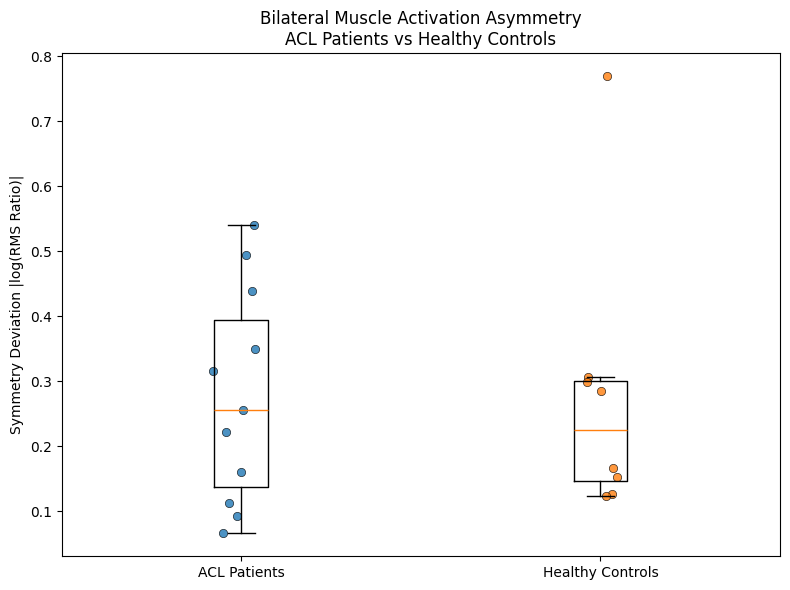

In [55]:
# Cell 52: Visualize symmetry deviation by cohort

import matplotlib.pyplot as plt
import numpy as np

acl_dev = primary_bilateral.loc[
    primary_bilateral["Cohort"] == "ACL Patient",
    "Symmetry_Deviation"
].dropna()

healthy_dev = primary_bilateral.loc[
    primary_bilateral["Cohort"] == "Healthy Control",
    "Symmetry_Deviation"
].dropna()

fig, ax = plt.subplots(figsize=(8, 6))

ax.boxplot(
    [acl_dev, healthy_dev],
    labels=["ACL Patients", "Healthy Controls"],
    showfliers=False
)

# Add individual observations with small horizontal jitter
rng = np.random.default_rng(42)

for i, values in enumerate([acl_dev, healthy_dev], start=1):
    x = rng.normal(i, 0.04, size=len(values))
    ax.scatter(
        x,
        values,
        alpha=0.8,
        edgecolor="black",
        linewidth=0.5
    )

ax.set_ylabel("Symmetry Deviation |log(RMS Ratio)|")
ax.set_title(
    "Bilateral Muscle Activation Asymmetry\n"
    "ACL Patients vs Healthy Controls"
)

plt.tight_layout()
plt.show()

/var/folders/0q/0939z_y55hj4mp2gkzrnm6040000gn/T/ipykernel_71926/1769650012.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


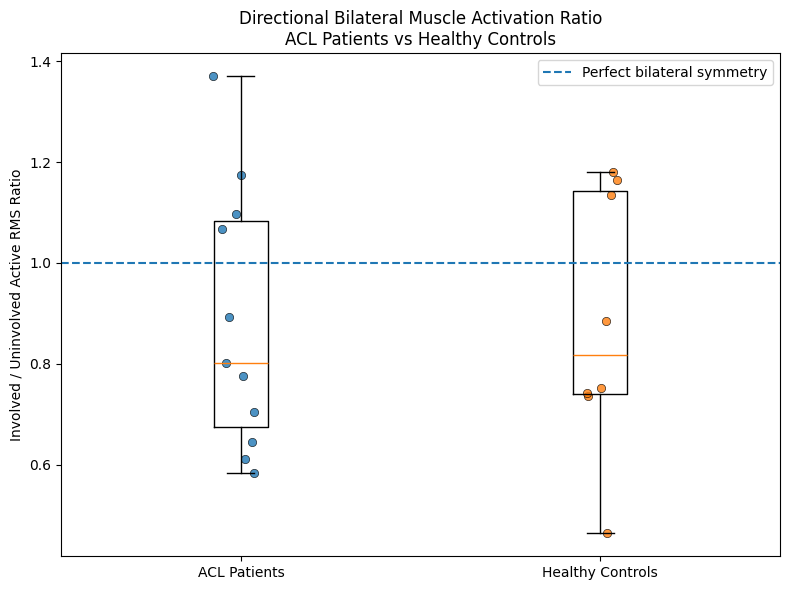

In [56]:
# Cell 53: Visualize directional RMS ratio

acl_ratio = primary_bilateral.loc[
    primary_bilateral["Cohort"] == "ACL Patient",
    "RMS_Ratio"
].dropna()

healthy_ratio = primary_bilateral.loc[
    primary_bilateral["Cohort"] == "Healthy Control",
    "RMS_Ratio"
].dropna()

fig, ax = plt.subplots(figsize=(8, 6))

ax.boxplot(
    [acl_ratio, healthy_ratio],
    labels=["ACL Patients", "Healthy Controls"],
    showfliers=False
)

rng = np.random.default_rng(42)

for i, values in enumerate([acl_ratio, healthy_ratio], start=1):
    x = rng.normal(i, 0.04, size=len(values))
    ax.scatter(
        x,
        values,
        alpha=0.8,
        edgecolor="black",
        linewidth=0.5
    )

ax.axhline(
    1,
    linestyle="--",
    linewidth=1.5,
    label="Perfect bilateral symmetry"
)

ax.set_ylabel("Involved / Uninvolved Active RMS Ratio")
ax.set_title(
    "Directional Bilateral Muscle Activation Ratio\n"
    "ACL Patients vs Healthy Controls"
)

ax.legend()

plt.tight_layout()
plt.show()

In [58]:
# Cell 54: Statistical comparison of symmetry deviation between cohorts

from scipy import stats
import numpy as np

acl_sym = primary_bilateral.loc[
    primary_bilateral["Cohort"] == "ACL Patient",
    "Symmetry_Deviation"
].dropna().to_numpy()

healthy_sym = primary_bilateral.loc[
    primary_bilateral["Cohort"] == "Healthy Control",
    "Symmetry_Deviation"
].dropna().to_numpy()


# --------------------------------------------------
# 1. Welch's t-test
# --------------------------------------------------

welch_result = stats.ttest_ind(
    acl_sym,
    healthy_sym,
    equal_var=False
)


# --------------------------------------------------
# 2. Mann-Whitney U test
# --------------------------------------------------

mw_result = stats.mannwhitneyu(
    acl_sym,
    healthy_sym,
    alternative="two-sided"
)


# --------------------------------------------------
# 3. Permutation test for difference in means
# --------------------------------------------------

observed_diff = acl_sym.mean() - healthy_sym.mean()

combined = np.concatenate([acl_sym, healthy_sym])

rng = np.random.default_rng(42)

n_perm = 10000

perm_diffs = np.empty(n_perm)

for i in range(n_perm):
    shuffled = rng.permutation(combined)

    perm_acl = shuffled[:len(acl_sym)]
    perm_healthy = shuffled[len(acl_sym):]

    perm_diffs[i] = perm_acl.mean() - perm_healthy.mean()

permutation_p = np.mean(
    np.abs(perm_diffs) >= abs(observed_diff)
)


# --------------------------------------------------
# 4. Hedges' g effect size
# --------------------------------------------------

n1 = len(acl_sym)
n2 = len(healthy_sym)

sd1 = np.std(acl_sym, ddof=1)
sd2 = np.std(healthy_sym, ddof=1)

pooled_sd = np.sqrt(
    ((n1 - 1) * sd1**2 + (n2 - 1) * sd2**2)
    / (n1 + n2 - 2)
)

cohens_d = (
    acl_sym.mean() - healthy_sym.mean()
) / pooled_sd

correction = 1 - (
    3 / (4 * (n1 + n2) - 9)
)

hedges_g = correction * cohens_d


# --------------------------------------------------
# Results
# --------------------------------------------------

print("ACL n:", n1)
print("Healthy n:", n2)

print("\nMean symmetry deviation")
print("ACL:", acl_sym.mean())
print("Healthy:", healthy_sym.mean())
print("Observed mean difference:", observed_diff)

print("\nWelch's t-test")
print("t-statistic:", welch_result.statistic)
print("p-value:", welch_result.pvalue)

print("\nMann-Whitney U test")
print("U-statistic:", mw_result.statistic)
print("p-value:", mw_result.pvalue)

print("\nPermutation test")
print("p-value:", permutation_p)

print("\nEffect size")
print("Cohen's d:", cohens_d)
print("Hedges' g:", hedges_g)

ACL n: 11
Healthy n: 8

Mean symmetry deviation
ACL: 0.2769661921591405
Healthy: 0.2784477090407603
Observed mean difference: -0.0014815168816198487

Welch's t-test
t-statistic: -0.016402681492850256
p-value: 0.9871673269891037

Mann-Whitney U test
U-statistic: 46.0
p-value: 0.9038924611680029

Permutation test
p-value: 0.988

Effect size
Cohen's d: -0.007949032268316263
Hedges' g: -0.0075931054503319525


In [59]:
# Cell 55: Bootstrap confidence interval and sensitivity analysis

import numpy as np
from scipy import stats

rng = np.random.default_rng(42)

# --------------------------------------------------
# 1. Bootstrap CI for difference in mean
#    symmetry deviation: ACL - Healthy
# --------------------------------------------------

n_boot = 10000
boot_diffs = np.empty(n_boot)

for i in range(n_boot):

    boot_acl = rng.choice(
        acl_sym,
        size=len(acl_sym),
        replace=True
    )

    boot_healthy = rng.choice(
        healthy_sym,
        size=len(healthy_sym),
        replace=True
    )

    boot_diffs[i] = (
        boot_acl.mean() -
        boot_healthy.mean()
    )

ci_lower, ci_upper = np.percentile(
    boot_diffs,
    [2.5, 97.5]
)

print("PRIMARY ANALYSIS")
print("----------------")
print("Observed mean difference (ACL - Healthy):",
      acl_sym.mean() - healthy_sym.mean())

print("95% bootstrap CI:",
      (ci_lower, ci_upper))


# --------------------------------------------------
# 2. Sensitivity analysis:
#    remove healthy4
# --------------------------------------------------

sensitivity_data = primary_bilateral[
    ~(
        (primary_bilateral["Cohort"] == "Healthy Control") &
        (primary_bilateral["Participant"] == "healthy4")
    )
].copy()

acl_sens = sensitivity_data.loc[
    sensitivity_data["Cohort"] == "ACL Patient",
    "Symmetry_Deviation"
].dropna().to_numpy()

healthy_sens = sensitivity_data.loc[
    sensitivity_data["Cohort"] == "Healthy Control",
    "Symmetry_Deviation"
].dropna().to_numpy()


print("\nSENSITIVITY ANALYSIS")
print("--------------------")

print("ACL n:", len(acl_sens))
print("Healthy n:", len(healthy_sens))

print("ACL mean:",
      acl_sens.mean())

print("Healthy mean:",
      healthy_sens.mean())

print("Mean difference:",
      acl_sens.mean() - healthy_sens.mean())


# Welch's t-test
welch_sens = stats.ttest_ind(
    acl_sens,
    healthy_sens,
    equal_var=False
)

print("\nWelch's t-test")
print("t-statistic:", welch_sens.statistic)
print("p-value:", welch_sens.pvalue)


# Mann-Whitney U
mw_sens = stats.mannwhitneyu(
    acl_sens,
    healthy_sens,
    alternative="two-sided"
)

print("\nMann-Whitney U")
print("U-statistic:", mw_sens.statistic)
print("p-value:", mw_sens.pvalue)


# --------------------------------------------------
# 3. Effect size after removing healthy4
# --------------------------------------------------

n1 = len(acl_sens)
n2 = len(healthy_sens)

sd1 = np.std(acl_sens, ddof=1)
sd2 = np.std(healthy_sens, ddof=1)

pooled_sd = np.sqrt(
    (
        (n1 - 1) * sd1**2 +
        (n2 - 1) * sd2**2
    ) /
    (n1 + n2 - 2)
)

cohens_d_sens = (
    acl_sens.mean() -
    healthy_sens.mean()
) / pooled_sd

correction = 1 - (
    3 / (4 * (n1 + n2) - 9)
)

hedges_g_sens = (
    correction * cohens_d_sens
)

print("\nEffect size")
print("Cohen's d:", cohens_d_sens)
print("Hedges' g:", hedges_g_sens)

PRIMARY ANALYSIS
----------------
Observed mean difference (ACL - Healthy): -0.0014815168816198487
95% bootstrap CI: (-0.1814515681566249, 0.15210423305622897)

SENSITIVITY ANALYSIS
--------------------
ACL n: 11
Healthy n: 7
ACL mean: 0.2769661921591405
Healthy mean: 0.20832899751974257
Mean difference: 0.06863719463939791

Welch's t-test
t-statistic: 1.1607296371635119
p-value: 0.26326861331241835

Mann-Whitney U
U-statistic: 46.0
p-value: 0.5360105580693816

Effect size
Cohen's d: 0.48902973057552745
Hedges' g: 0.46574260054812133


In [60]:
# Cell 56: Build a robust healthy-reference asymmetry score

import numpy as np
import pandas as pd

# --------------------------------------------------
# Healthy reference distribution
# Use all QC-valid healthy participants in the
# primary analysis.
# --------------------------------------------------

healthy_reference = primary_bilateral.loc[
    primary_bilateral["Cohort"] == "Healthy Control",
    "Symmetry_Deviation"
].dropna()

healthy_median = healthy_reference.median()

mad = np.median(
    np.abs(healthy_reference - healthy_median)
)

print("Healthy reference")
print("-----------------")
print("N:", len(healthy_reference))
print("Median symmetry deviation:", healthy_median)
print("MAD:", mad)


# --------------------------------------------------
# Robust z-like score
#
# Positive = more asymmetric than healthy median
# Negative = less asymmetric than healthy median
# --------------------------------------------------

primary_bilateral["Robust_Asymmetry_Score"] = (
    primary_bilateral["Symmetry_Deviation"] -
    healthy_median
) / mad


# --------------------------------------------------
# Healthy percentile
#
# Percentage of healthy controls with symmetry
# deviation <= this participant
# --------------------------------------------------

def healthy_percentile(value):
    return (
        np.mean(healthy_reference <= value) * 100
    )


primary_bilateral["Healthy_Percentile"] = (
    primary_bilateral["Symmetry_Deviation"]
    .apply(healthy_percentile)
)


# --------------------------------------------------
# Display ACL patients
# --------------------------------------------------

acl_profile = (
    primary_bilateral[
        primary_bilateral["Cohort"] == "ACL Patient"
    ][
        [
            "Participant",
            "Involved_RMS",
            "Uninvolved_RMS",
            "RMS_Ratio",
            "Symmetry_Deviation",
            "Robust_Asymmetry_Score",
            "Healthy_Percentile"
        ]
    ]
    .sort_values(
        "Symmetry_Deviation",
        ascending=False
    )
)

display(
    acl_profile.round(4)
)

Healthy reference
-----------------
N: 8
Median symmetry deviation: 0.22553932767071333
MAD: 0.07736828083219638


,Participant,Involved_RMS,Uninvolved_RMS,RMS_Ratio,Symmetry_Deviation,Robust_Asymmetry_Score,Healthy_Percentile
10,patient11,0.0001,0.0002,0.5826,0.5402,4.0670,87.5
0,patient1,0.0002,0.0003,0.6101,0.4941,3.4715,87.5
2,patient3,0.0001,0.0002,0.6446,0.4391,2.7603,87.5
3,patient4,0.0002,0.0003,0.7047,0.3500,1.6086,87.5
4,patient5,0.0003,0.0002,1.3708,0.3154,1.1615,87.5
6,patient7,0.0001,0.0001,0.7749,0.2550,0.3805,50.0
1,patient2,0.0001,0.0001,0.8014,0.2213,-0.0543,50.0
8,patient9,0.0002,0.0002,1.1740,0.1604,-0.8417,37.5
9,patient10,0.0002,0.0002,0.8932,0.1130,-1.4549,0.0
7,patient8,0.0001,0.0001,1.0968,0.0924,-1.7212,0.0


In [61]:
# Cell 57: Build participant-level rehabilitation profiles

import numpy as np
import pandas as pd


# --------------------------------------------------
# 1. Direction of bilateral activation difference
# --------------------------------------------------

def activation_direction(ratio, tolerance=0.10):
    
    if ratio < (1 - tolerance):
        return "Involved side lower"
    
    elif ratio > (1 + tolerance):
        return "Involved side higher"
    
    else:
        return "Approximately symmetric"


primary_bilateral["Activation_Direction"] = (
    primary_bilateral["RMS_Ratio"]
    .apply(activation_direction)
)


# --------------------------------------------------
# 2. Exploratory asymmetry category
#
# Based on robust distance from the healthy median.
# These are analytical categories, NOT clinical cutoffs.
# --------------------------------------------------

def asymmetry_category(score):
    
    if score < 1:
        return "Within reference range"
    
    elif score < 2:
        return "Moderately elevated"
    
    else:
        return "Highly elevated"


primary_bilateral["Asymmetry_Category"] = (
    primary_bilateral["Robust_Asymmetry_Score"]
    .apply(asymmetry_category)
)


# --------------------------------------------------
# 3. Difference from perfect bilateral symmetry
#    expressed as percentage
# --------------------------------------------------

primary_bilateral["Activation_Difference_Pct"] = (
    np.abs(
        primary_bilateral["RMS_Ratio"] - 1
    ) * 100
)


# --------------------------------------------------
# 4. Create ACL rehabilitation profile
# --------------------------------------------------

acl_rehab_profile = (
    primary_bilateral[
        primary_bilateral["Cohort"] == "ACL Patient"
    ][
        [
            "Participant",
            "Involved_RMS",
            "Uninvolved_RMS",
            "RMS_Ratio",
            "Activation_Difference_Pct",
            "Activation_Direction",
            "Symmetry_Deviation",
            "Robust_Asymmetry_Score",
            "Healthy_Percentile",
            "Asymmetry_Category"
        ]
    ]
    .sort_values(
        "Robust_Asymmetry_Score",
        ascending=False
    )
    .reset_index(drop=True)
)


display(acl_rehab_profile.round(4))


print("\nActivation direction counts:")
print(
    acl_rehab_profile[
        "Activation_Direction"
    ].value_counts()
)


print("\nAsymmetry category counts:")
print(
    acl_rehab_profile[
        "Asymmetry_Category"
    ].value_counts()
)

,Participant,Involved_RMS,Uninvolved_RMS,RMS_Ratio,Activation_Difference_Pct,Activation_Direction,Symmetry_Deviation,Robust_Asymmetry_Score,Healthy_Percentile,Asymmetry_Category
0,patient11,0.0001,0.0002,0.5826,41.7364,Involved side lower,0.5402,4.0670,87.5,Highly elevated
1,patient1,0.0002,0.0003,0.6101,38.9895,Involved side lower,0.4941,3.4715,87.5,Highly elevated
2,patient3,0.0001,0.0002,0.6446,35.5382,Involved side lower,0.4391,2.7603,87.5,Highly elevated
3,patient4,0.0002,0.0003,0.7047,29.5310,Involved side lower,0.3500,1.6086,87.5,Moderately elevated
4,patient5,0.0003,0.0002,1.3708,37.0808,Involved side higher,0.3154,1.1615,87.5,Moderately elevated
5,patient7,0.0001,0.0001,0.7749,22.5067,Involved side lower,0.2550,0.3805,50.0,Within reference range
6,patient2,0.0001,0.0001,0.8014,19.8553,Involved side lower,0.2213,-0.0543,50.0,Within reference range
7,patient9,0.0002,0.0002,1.1740,17.4006,Involved side higher,0.1604,-0.8417,37.5,Within reference range
8,patient10,0.0002,0.0002,0.8932,10.6827,Involved side lower,0.1130,-1.4549,0.0,Within reference range
9,patient8,0.0001,0.0001,1.0968,9.6771,Approximately symmetric,0.0924,-1.7212,0.0,Within reference range



Activation direction counts:
Activation_Direction
Involved side lower        7
Involved side higher       2
Approximately symmetric    2
Name: count, dtype: int64

Asymmetry category counts:
Asymmetry_Category
Within reference range    6
Highly elevated           3
Moderately elevated       2
Name: count, dtype: int64


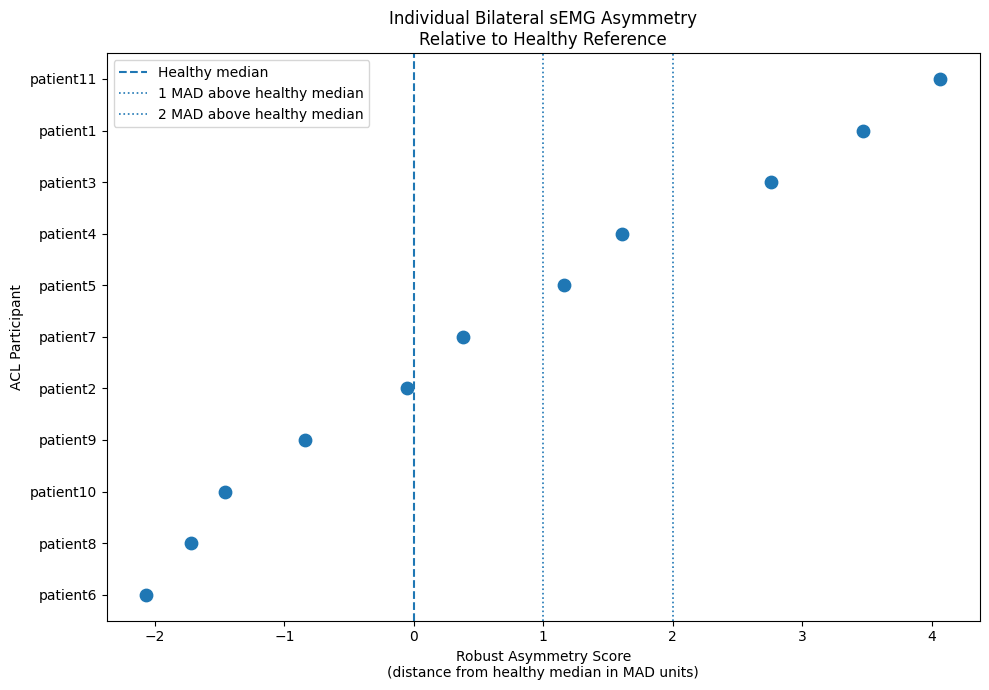

In [62]:
# Cell 58: Visualize ACL asymmetry relative to healthy reference

import matplotlib.pyplot as plt
import numpy as np

plot_data = acl_rehab_profile.sort_values(
    "Robust_Asymmetry_Score",
    ascending=True
).copy()

fig, ax = plt.subplots(figsize=(10, 7))

y = np.arange(len(plot_data))

ax.scatter(
    plot_data["Robust_Asymmetry_Score"],
    y,
    s=80
)

# Healthy median reference
ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5,
    label="Healthy median"
)

# Exploratory reference thresholds
ax.axvline(
    1,
    linestyle=":",
    linewidth=1.2,
    label="1 MAD above healthy median"
)

ax.axvline(
    2,
    linestyle=":",
    linewidth=1.2,
    label="2 MAD above healthy median"
)

ax.set_yticks(y)
ax.set_yticklabels(plot_data["Participant"])

ax.set_xlabel(
    "Robust Asymmetry Score\n"
    "(distance from healthy median in MAD units)"
)

ax.set_ylabel("ACL Participant")

ax.set_title(
    "Individual Bilateral sEMG Asymmetry\n"
    "Relative to Healthy Reference"
)

ax.legend()

plt.tight_layout()
plt.show()

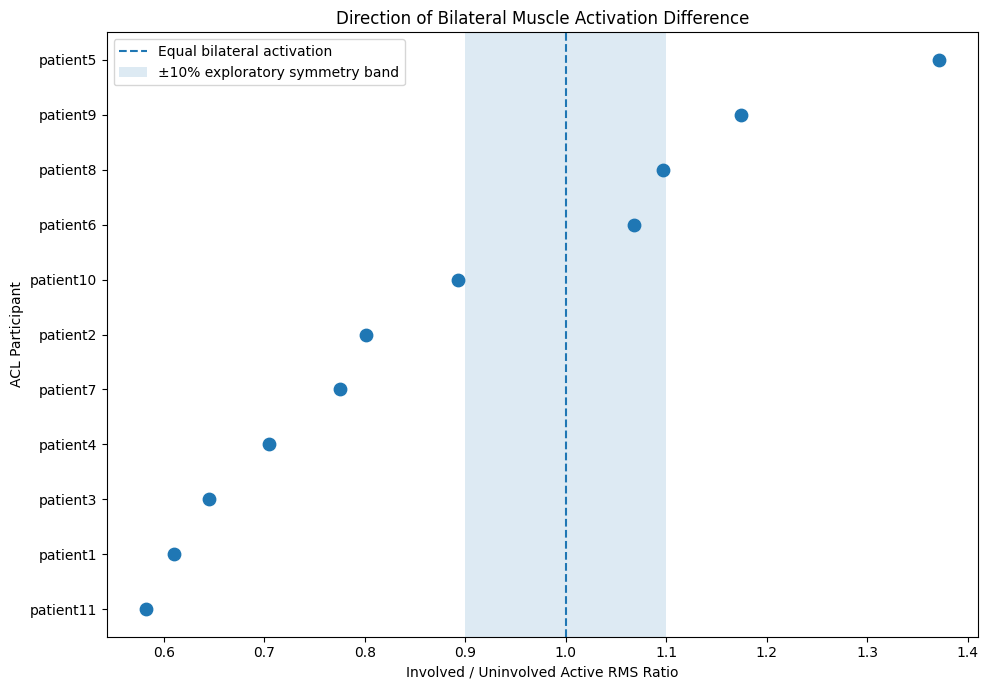

In [63]:
# Cell 59: Visualize directional bilateral activation ratios

plot_ratio = acl_rehab_profile.sort_values(
    "RMS_Ratio",
    ascending=True
).copy()

fig, ax = plt.subplots(figsize=(10, 7))

y = np.arange(len(plot_ratio))

ax.scatter(
    plot_ratio["RMS_Ratio"],
    y,
    s=80
)

ax.axvline(
    1,
    linestyle="--",
    linewidth=1.5,
    label="Equal bilateral activation"
)

# ±10% exploratory symmetry band
ax.axvspan(
    0.9,
    1.1,
    alpha=0.15,
    label="±10% exploratory symmetry band"
)

ax.set_yticks(y)
ax.set_yticklabels(plot_ratio["Participant"])

ax.set_xlabel(
    "Involved / Uninvolved Active RMS Ratio"
)

ax.set_ylabel("ACL Participant")

ax.set_title(
    "Direction of Bilateral Muscle Activation Difference"
)

ax.legend()

plt.tight_layout()
plt.show()

In [65]:
# Cell 60: Build final participant-level feature table

# Start from bilateral participant table
final_features = bilateral_active.copy()

# --------------------------------------------------
# Recalculate bilateral metrics
# --------------------------------------------------

final_features["RMS_Ratio"] = (
    final_features["Involved_RMS"] /
    final_features["Uninvolved_RMS"]
)

final_features["Symmetry_Deviation"] = np.abs(
    np.log(final_features["RMS_Ratio"])
)


# --------------------------------------------------
# Add QC/activity information
# --------------------------------------------------

inv_qc = qc_final[
    qc_final["Group"].isin(
        ["Patient - Involved", "Healthy - Involved"]
    )
][
    [
        "Participant",
        "Valid_Contractions",
        "Active_Fraction",
        "QC_Status"
    ]
].copy()

inv_qc = inv_qc.rename(
    columns={
        "Valid_Contractions": "Involved_Valid_Contractions",
        "Active_Fraction": "Involved_Active_Fraction",
        "QC_Status": "Involved_QC_Status"
    }
)


uninv_qc = qc_final[
    qc_final["Group"].isin(
        ["Patient - Uninvolved", "Healthy - Uninvolved"]
    )
][
    [
        "Participant",
        "Valid_Contractions",
        "Active_Fraction",
        "QC_Status"
    ]
].copy()

uninv_qc = uninv_qc.rename(
    columns={
        "Valid_Contractions": "Uninvolved_Valid_Contractions",
        "Active_Fraction": "Uninvolved_Active_Fraction",
        "QC_Status": "Uninvolved_QC_Status"
    }
)


# Merge QC information
final_features = final_features.merge(
    inv_qc,
    on="Participant",
    how="left"
)

final_features = final_features.merge(
    uninv_qc,
    on="Participant",
    how="left"
)


# --------------------------------------------------
# Activation difference and direction
# --------------------------------------------------

final_features["Activation_Difference_Pct"] = (
    np.abs(final_features["RMS_Ratio"] - 1) * 100
)


def classify_direction(ratio):
    if pd.isna(ratio):
        return np.nan
    elif ratio < 0.90:
        return "Involved side lower"
    elif ratio > 1.10:
        return "Involved side higher"
    else:
        return "Approximately symmetric"


final_features["Activation_Direction"] = (
    final_features["RMS_Ratio"]
    .apply(classify_direction)
)


# --------------------------------------------------
# Healthy reference
# IMPORTANT: use QC-valid healthy bilateral records
# --------------------------------------------------

healthy_reference = final_features[
    (final_features["Cohort"] == "Healthy Control") &
    (final_features["Involved_QC_Status"] == "Pass") &
    (final_features["Uninvolved_QC_Status"] == "Pass") &
    final_features["Symmetry_Deviation"].notna()
].copy()

healthy_median = (
    healthy_reference["Symmetry_Deviation"].median()
)

healthy_mad = np.median(
    np.abs(
        healthy_reference["Symmetry_Deviation"]
        - healthy_median
    )
)


final_features["Robust_Asymmetry_Score"] = (
    final_features["Symmetry_Deviation"] -
    healthy_median
) / healthy_mad


# --------------------------------------------------
# Exploratory category
# --------------------------------------------------

def classify_asymmetry(score):
    if pd.isna(score):
        return np.nan
    elif score > 2:
        return "Highly elevated"
    elif score > 1:
        return "Moderately elevated"
    else:
        return "Within reference range"


final_features["Asymmetry_Category"] = (
    final_features["Robust_Asymmetry_Score"]
    .apply(classify_asymmetry)
)


# --------------------------------------------------
# Primary-analysis inclusion
# --------------------------------------------------

final_features["Primary_Analysis"] = (
    final_features["Involved_QC_Status"].eq("Pass")
    &
    final_features["Uninvolved_QC_Status"].eq("Pass")
)


# --------------------------------------------------
# Select final columns
# --------------------------------------------------

final_features = final_features[
    [
        "Cohort",
        "Participant",
        "Involved_RMS",
        "Uninvolved_RMS",
        "RMS_Ratio",
        "Symmetry_Deviation",
        "Involved_Valid_Contractions",
        "Uninvolved_Valid_Contractions",
        "Involved_Active_Fraction",
        "Uninvolved_Active_Fraction",
        "Activation_Difference_Pct",
        "Activation_Direction",
        "Robust_Asymmetry_Score",
        "Asymmetry_Category",
        "Involved_QC_Status",
        "Uninvolved_QC_Status",
        "Primary_Analysis"
    ]
].copy()


final_features = final_features.sort_values(
    ["Cohort", "Participant"]
).reset_index(drop=True)


print("Final feature table shape:", final_features.shape)

display(final_features)

Final feature table shape: (22, 17)


,Cohort,Participant,Involved_RMS,Uninvolved_RMS,RMS_Ratio,Symmetry_Deviation,Involved_Valid_Contractions,Uninvolved_Valid_Contractions,Involved_Active_Fraction,Uninvolved_Active_Fraction,Activation_Difference_Pct,Activation_Direction,Robust_Asymmetry_Score,Asymmetry_Category,Involved_QC_Status,Uninvolved_QC_Status,Primary_Analysis
0,ACL Patient,patient1,0.000154,0.000253,0.610105,0.494124,9,9,0.387989,0.375439,38.989485,Involved side lower,3.471508,Highly elevated,Pass,Pass,True
1,ACL Patient,patient10,0.000181,0.000202,0.893173,0.112975,8,9,0.444040,0.421211,10.682671,Involved side lower,-1.454920,Within reference range,Pass,Pass,True
2,ACL Patient,patient11,0.000095,0.000164,0.582636,0.540193,9,9,0.468607,0.385836,41.736444,Involved side lower,4.066965,Highly elevated,Pass,Pass,True
3,ACL Patient,patient12,0.000052,0.000117,0.449514,0.799587,5,9,0.305496,0.359225,55.048551,Involved side lower,7.419680,Highly elevated,Review - low contraction count,Pass,False
4,ACL Patient,patient2,0.000065,0.000081,0.801447,0.221336,9,8,0.316977,0.405487,19.855263,Involved side lower,-0.054329,Within reference range,Pass,Pass,True
5,ACL Patient,patient3,0.000113,0.000176,0.644618,0.439098,8,9,0.386260,0.362152,35.538247,Involved side lower,2.760289,Highly elevated,Pass,Pass,True
6,ACL Patient,patient4,0.000200,0.000284,0.704690,0.349998,9,10,0.441862,0.404077,29.531036,Involved side lower,1.608650,Moderately elevated,Pass,Pass,True
7,ACL Patient,patient5,0.000328,0.000239,1.370808,0.315400,9,9,0.378230,0.385328,37.080816,Involved side higher,1.161473,Moderately elevated,Pass,Pass,True
8,ACL Patient,patient6,0.000259,0.000243,1.067943,0.065734,8,9,0.418450,0.398995,6.794258,Approximately symmetric,-2.065515,Within reference range,Pass,Pass,True
9,ACL Patient,patient7,0.000084,0.000108,0.774933,0.254978,9,9,0.515712,0.363324,22.506654,Involved side lower,0.380502,Within reference range,Pass,Pass,True


In [66]:
# Cell 61: Validate final participant-level feature table

print("Number of participants:")
print(final_features["Cohort"].value_counts())

print("\nPrimary analysis inclusion:")
print(
    final_features
    .groupby("Cohort")["Primary_Analysis"]
    .agg(["sum", "count"])
)

print("\nMissing values:")
print(final_features.isna().sum())

print("\nQC combinations:")
display(
    final_features[
        [
            "Cohort",
            "Participant",
            "Involved_QC_Status",
            "Uninvolved_QC_Status",
            "Primary_Analysis"
        ]
    ]
)

print("\nFinal columns:")
print(final_features.columns.tolist())

Number of participants:
Cohort
ACL Patient        12
Healthy Control    10
Name: count, dtype: int64

Primary analysis inclusion:
                 sum  count
Cohort                     
ACL Patient       11     12
Healthy Control    8     10

Missing values:
Cohort                           0
Participant                      0
Involved_RMS                     0
Uninvolved_RMS                   1
RMS_Ratio                        1
Symmetry_Deviation               1
Involved_Valid_Contractions      0
Uninvolved_Valid_Contractions    0
Involved_Active_Fraction         0
Uninvolved_Active_Fraction       0
Activation_Difference_Pct        1
Activation_Direction             1
Robust_Asymmetry_Score           1
Asymmetry_Category               1
Involved_QC_Status               0
Uninvolved_QC_Status             0
Primary_Analysis                 0
dtype: int64

QC combinations:


,Cohort,Participant,Involved_QC_Status,Uninvolved_QC_Status,Primary_Analysis
0,ACL Patient,patient1,Pass,Pass,True
1,ACL Patient,patient10,Pass,Pass,True
2,ACL Patient,patient11,Pass,Pass,True
3,ACL Patient,patient12,Review - low contraction count,Pass,False
4,ACL Patient,patient2,Pass,Pass,True
5,ACL Patient,patient3,Pass,Pass,True
6,ACL Patient,patient4,Pass,Pass,True
7,ACL Patient,patient5,Pass,Pass,True
8,ACL Patient,patient6,Pass,Pass,True
9,ACL Patient,patient7,Pass,Pass,True



Final columns:
['Cohort', 'Participant', 'Involved_RMS', 'Uninvolved_RMS', 'RMS_Ratio', 'Symmetry_Deviation', 'Involved_Valid_Contractions', 'Uninvolved_Valid_Contractions', 'Involved_Active_Fraction', 'Uninvolved_Active_Fraction', 'Activation_Difference_Pct', 'Activation_Direction', 'Robust_Asymmetry_Score', 'Asymmetry_Category', 'Involved_QC_Status', 'Uninvolved_QC_Status', 'Primary_Analysis']


In [67]:
# Cell 62: Export final participant-level feature dataset

from pathlib import Path

OUTPUT_DIR = Path("../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

output_path = OUTPUT_DIR / "bilateral_semg_features.csv"

final_features.to_csv(
    output_path,
    index=False
)

print("Saved final feature dataset to:")
print(output_path)

print("\nDataset shape:")
print(final_features.shape)

print("\nPrimary-analysis participants:")
print(
    final_features[
        final_features["Primary_Analysis"]
    ]["Cohort"].value_counts()
)

Saved final feature dataset to:
../data/processed/bilateral_semg_features.csv

Dataset shape:
(22, 17)

Primary-analysis participants:
Cohort
ACL Patient        11
Healthy Control     8
Name: count, dtype: int64


## Summary

This notebook developed a reproducible pipeline for extracting participant-level
bilateral muscle activation features from raw sEMG recordings.

### Processing pipeline

Raw sEMG signals were:

1. inspected for signal quality and recording anomalies;
2. rectified and smoothed to obtain an activation envelope;
3. segmented into active contraction periods using an adaptive threshold;
4. filtered to remove implausibly short contraction regions;
5. summarized using active-region RMS and contraction-level features;
6. paired between involved and uninvolved limbs;
7. evaluated using bilateral activation ratios and symmetry deviation.

### Quality control

Participant-level quality control identified three recordings requiring special
consideration:

- **patient12 involved limb:** low number of valid contractions;
- **healthy8 uninvolved limb:** no valid contractions detected;
- **healthy9 uninvolved limb:** unusually high activation amplitude.

The primary analysis therefore included **11 ACL patients and 8 healthy controls**.

### Bilateral activation metrics

Directional bilateral activation was quantified as:

\[
R = \frac{RMS_{involved}}{RMS_{uninvolved}}
\]

where values below 1 indicate lower activation on the involved side and values
above 1 indicate higher activation on the involved side.

Magnitude of bilateral asymmetry was quantified as:

\[
D = |\log(R)|
\]

so that deviations in either direction contribute positively to the asymmetry
measure.

### Main findings

At the group level, ACL patients did not demonstrate greater average bilateral
asymmetry than healthy controls in this sample. The mean symmetry deviation was
approximately **0.277 for ACL patients** and **0.278 for healthy controls**.

The observed group difference was close to zero and was not statistically
significant across Welch's t-test, Mann–Whitney U test, and permutation testing.

However, participant-level analysis revealed substantial heterogeneity among ACL
patients. Several individuals showed markedly elevated asymmetry relative to the
healthy reference distribution, while others showed approximately symmetric
activation.

This suggests that participant-level bilateral activation patterns may contain
information that is obscured by group averages.

### Output

The processed participant-level feature dataset is exported as:

`../data/processed/bilateral_semg_features.csv`

This dataset will serve as the input for subsequent recovery-oriented analysis
and modeling.